## First time setup / installation

This notebook needs **Jupyter** plus several scientific-Python / deep-learning
packages, including [`plenoptic`](https://github.com/plenoptic-org/plenoptic)
for the steerable-pyramid model. Recommended: a dedicated conda environment
named `viz`.

**First, check your Mac's architecture** -- this changes which dependency
versions you need:

```bash
python3 -c "import platform; print(platform.machine())"
# arm64  -> Apple Silicon (M1/M2/M3/...)
# x86_64 -> Intel
```

```bash
# 1. Create and activate a new conda environment named "viz"
conda create -n viz -c conda-forge python=3.11 -y
conda activate viz

# 2. Install Jupyter itself (needed to open/run this notebook)
pip install jupyter ipykernel

# 3. Install this notebook's PINNED dependencies -- pick the file matching
#    your architecture from the check above (do NOT `pip install` these
#    packages unpinned -- see why below):
pip install -r requirements.txt            # Apple Silicon (arm64)
pip install -r requirements-intel-mac.txt   # Intel (x86_64)

# 4. Register "viz" as a selectable Jupyter kernel
python -m ipykernel install --user --name viz --display-name "Python (viz)"
```

**Why pinned, and why two files?** `plenoptic>=2.0` removed the
`plenoptic.simulate` module this notebook imports (both files pin
`plenoptic==1.3.1`, which still has it). Separately, PyTorch dropped
Intel-macOS wheels after `torch==2.2.2`, and that version was built against
NumPy 1.x's ABI -- so Intel Macs additionally need `numpy<2`, Python capped
at 3.11, and an older `opencv-python` (newer releases require `numpy>=2`,
which would conflict). Apple Silicon has no such ceiling. See `AGENTS.md`
for the full story if you need to change these pins.

**Running it:** `conda activate viz` then `jupyter notebook` (or
`jupyter lab`). This notebook's saved kernel metadata already points at the
`viz` kernel from step 4, so it should launch with the right environment
automatically -- just double check the kernel name shown in the notebook UI.

If you see a `ModuleNotFoundError` (e.g. for `ipdb`, or
`plenoptic.simulate`) after following the steps above, it usually means
Jupyter is running a *different* kernel/environment than `viz` -- check
`jupyter kernelspec list` and the kernel name shown in the top-right of the
notebook UI.

## model_DriftingGratings

1) Runs steerable pyramid on 2 drifting grating stimulus sets (Cartesian, Polar)
2) Runs various types of normalization, and plots the output magnitude per polar angle

## DONE:

- Added SF channels to analysis, global intercept is higher for polar stimuli
- Applied the imbalance to all SF channels (before was only the "match")
- Applied 4D convolution (across n_SF, n_ORIs, X, Y) - this pads all dimensions (ori, sf, x, y treated as the same)
    -   Model 1) Divisive norm
    -   Model 2) Divisive norm with exponential suppression
    -   Model 3) Ori-tuned divisive norm
    -   Model 6) Normalization by StimHomogeneity (consistency of channel distribution)
          - I think this conceptually combines Anisotropy model and suppressive exponent model (& consistent w/ Cavanagh et al.?)
    -   TO VISUALIZE OUTPUT: taking an average across SF channels to compress output to ORI channels
- For the anisotropy models, there is no convolution, so I just average across SF channels before computing std
    -   Model 4) Orientation-anisoptropy model (input: average SF, collapse space, then compute global ori std)
    -   Model 5) Orientation-anisoptropy model 2 (same as above but do not collapse space)
    -   TO VISUALIZE OUTPUT: averaging across SF channels is not needed, done before the normalization
- Created a new model (Model 6) to address:
      (1) something that suppresses homogeneity (like the orientation anisotropy model)
      (2) uses suppressive exponent
      (2) might(?) explain results from Cavanagh, Bair & Movshon: suppression determined by stimulus homogeneity
- Added the radial & cardinal weights based on human behavior
    - Cardinal is just a weight on the cardinal channels
    - Radial is a weight applied to each channel with the corresponding polar angles with the full weight, and orthogonal directions as no weight (e.g., vertical channel would have a gradient that peaks at 90 and 270)
- Added radial analysis
- Converted to energy rather than magnitude

## Qs:

- For 4D gaussian convolution, I am using the a symmetric std in all 4Ds. This doesn't seem right. How to decide on sigma for other Ds?
- For some reason, the balanced population shows greater magnitude for local radial energy (but equal distr. in the local cartesian orientations).
- Regardless of this issue, the radial overrepresentation results in suppression for radial
      - Maybe an alternative is to think of cardinal overepresentation as suppression, and polar as facilitation.
      - Supported by neural data. Could highlight different mechanisms: cardinal=greater neurons; polar=feedback or lateral conn?
- For anistropy model,
      - I can implement graded gauss for ori -- but for now, I am doing large vs small gauss like Fang .. Winawer 2023 paper.
      - How to treat SF (Fang et al. sum SF after converting to energy)? Same with StimHomogeneity model?

## TO DO:
- Plot difference relative to the mean
- Log: how big is the normalization pool (vary this by 3 numbers--see how the output changes)
- Use von mise instead of linear ramp for radial (Fang paper)
- Add more orientation channels?
      - Check that adding more orientations updates everything in the code dynamically
- Visualize imbalance over theta (1d plot)
- Scale RF with SF... ? This would be harder to implement..
- Add polar cardinal asymmetry?
- Orientation anisotropy model- probably need to add a spatial window-right now both models compute global std.
- Literature review of suppressive drive as exponent (untuned?)
      - Check out Kough, Poggio for suppression exp. (summarize)
      - Adam Cohen - gated normalization
-Think about novel predictions (brain or behavior): vary contrast, adaptation, natural scenes.


In [34]:
# --- Setup ---
# If imports below fail (e.g. "No module named 'ipdb'" or
# "No module named 'plenoptic.simulate'"), see the installation
# instructions in the markdown cell above (or README.md). Short version:
#   python3 -c "import platform; print(platform.machine())"  # arm64 or x86_64?
#   conda create -n viz -c conda-forge python=3.11 -y && conda activate viz
#   pip install jupyter ipykernel
#   pip install -r requirements.txt             # if arm64 (Apple Silicon)
#   pip install -r requirements-intel-mac.txt    # if x86_64 (Intel)
#   python -m ipykernel install --user --name viz --display-name "Python (viz)"
# Then select the "Python (viz)" kernel for this notebook.

import contextlib
import itertools
import os
import ipdb
import sys
import json
from PIL import Image
import pandas as pd
import seaborn as sns
import cv2
from itertools import product
from matplotlib import colors
import copy

from helper_functions import pyrmodel
from helper_functions import utils_image
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from tqdm.auto import tqdm

import plenoptic as po
from plenoptic.simulate import SteerablePyramidFreq
from plenoptic.tools.data import to_numpy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
# this notebook uses torchvision, which is an optional dependency.
# if this fails, install torchvision in your plenoptic environment
# and restart the notebook kernel.
try:
    import torchvision
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "optional dependency torchvision not found!"
        " please install it in your plenoptic environment "
        "and restart the notebook kernel"
    )
import torchvision.transforms as transforms

dtype = torch.float32

# handle for tensors (use GPU if possible)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")  # Apple Silicon / Metal-capable GPU
else:
    DEVICE = torch.device("cpu")

# magic commands to auto-reload imported modules anytime they are changed on disk
%load_ext autoreload
%autoreload 2

# so that relative sizes of axes created by po.imshow and others look right
plt.rcParams["figure.dpi"] = 72

%matplotlib inline

plt.rcParams["animation.html"] = "html5"
# use single-threaded ffmpeg for animation writer
plt.rcParams["animation.writer"] = "ffmpeg"
plt.rcParams["animation.ffmpeg_args"] = ["-threads", "1"]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
DEVICE

device(type='mps')

In [37]:
# make the stimulus diameter 870 pixels, and image 896 pixels, padding of 13 pixels per edge
# stimulus diameter is 24.4 deg, 870 pixels. So adjust degrees based on this ratio.

img_size = 896                                     # limited by sqrt n_sf x ;
exp_stim_diamDeg = 24.4                            # needed to make stimulus approx the same as in experiment

x = int(np.round(img_size*0.85))                   # compute 97% of the img_size
x = x if x % 2 == 0 else x+1                       # if its odd, subtract 1 to make it even

img_size_nonPadded = x
pixpdeg = x/exp_stim_diamDeg
padded_img_degrees = img_size/pixpdeg              # derive degrees of padded image

############################################################################

n_ori = 4
n_sf = 6


# NOTE: kept on CPU regardless of DEVICE -- the steerable pyramid uses
# torch.fft.fft2 on complex tensors internally (is_complex=True below),
# and PyTorch's MPS backend (Apple Silicon/Metal GPUs) does not support
# complex dtypes for FFT ops as of torch 2.2.2, so this raises a
# 'ComplexFloat ... does not have support for that dtype' error on MPS.
# This step is cheap anyway (~5s of a ~45s total run) -- the real
# runtime cost is in the normalization functions below, which ARE
# GPU-accelerated via DEVICE/MPS where available (see utils_image.py's
# gaussian_filter_gpu).
my_model = pyrmodel.SteerablePyramidSF(n_ori=n_ori,
                                       n_sf=n_sf,
                                       img_size=img_size,
                                       img_degrees=padded_img_degrees,
                                       is_complex=True,
                                       downsample=False,
                                       tight_frame=True,
                                       device='cpu')


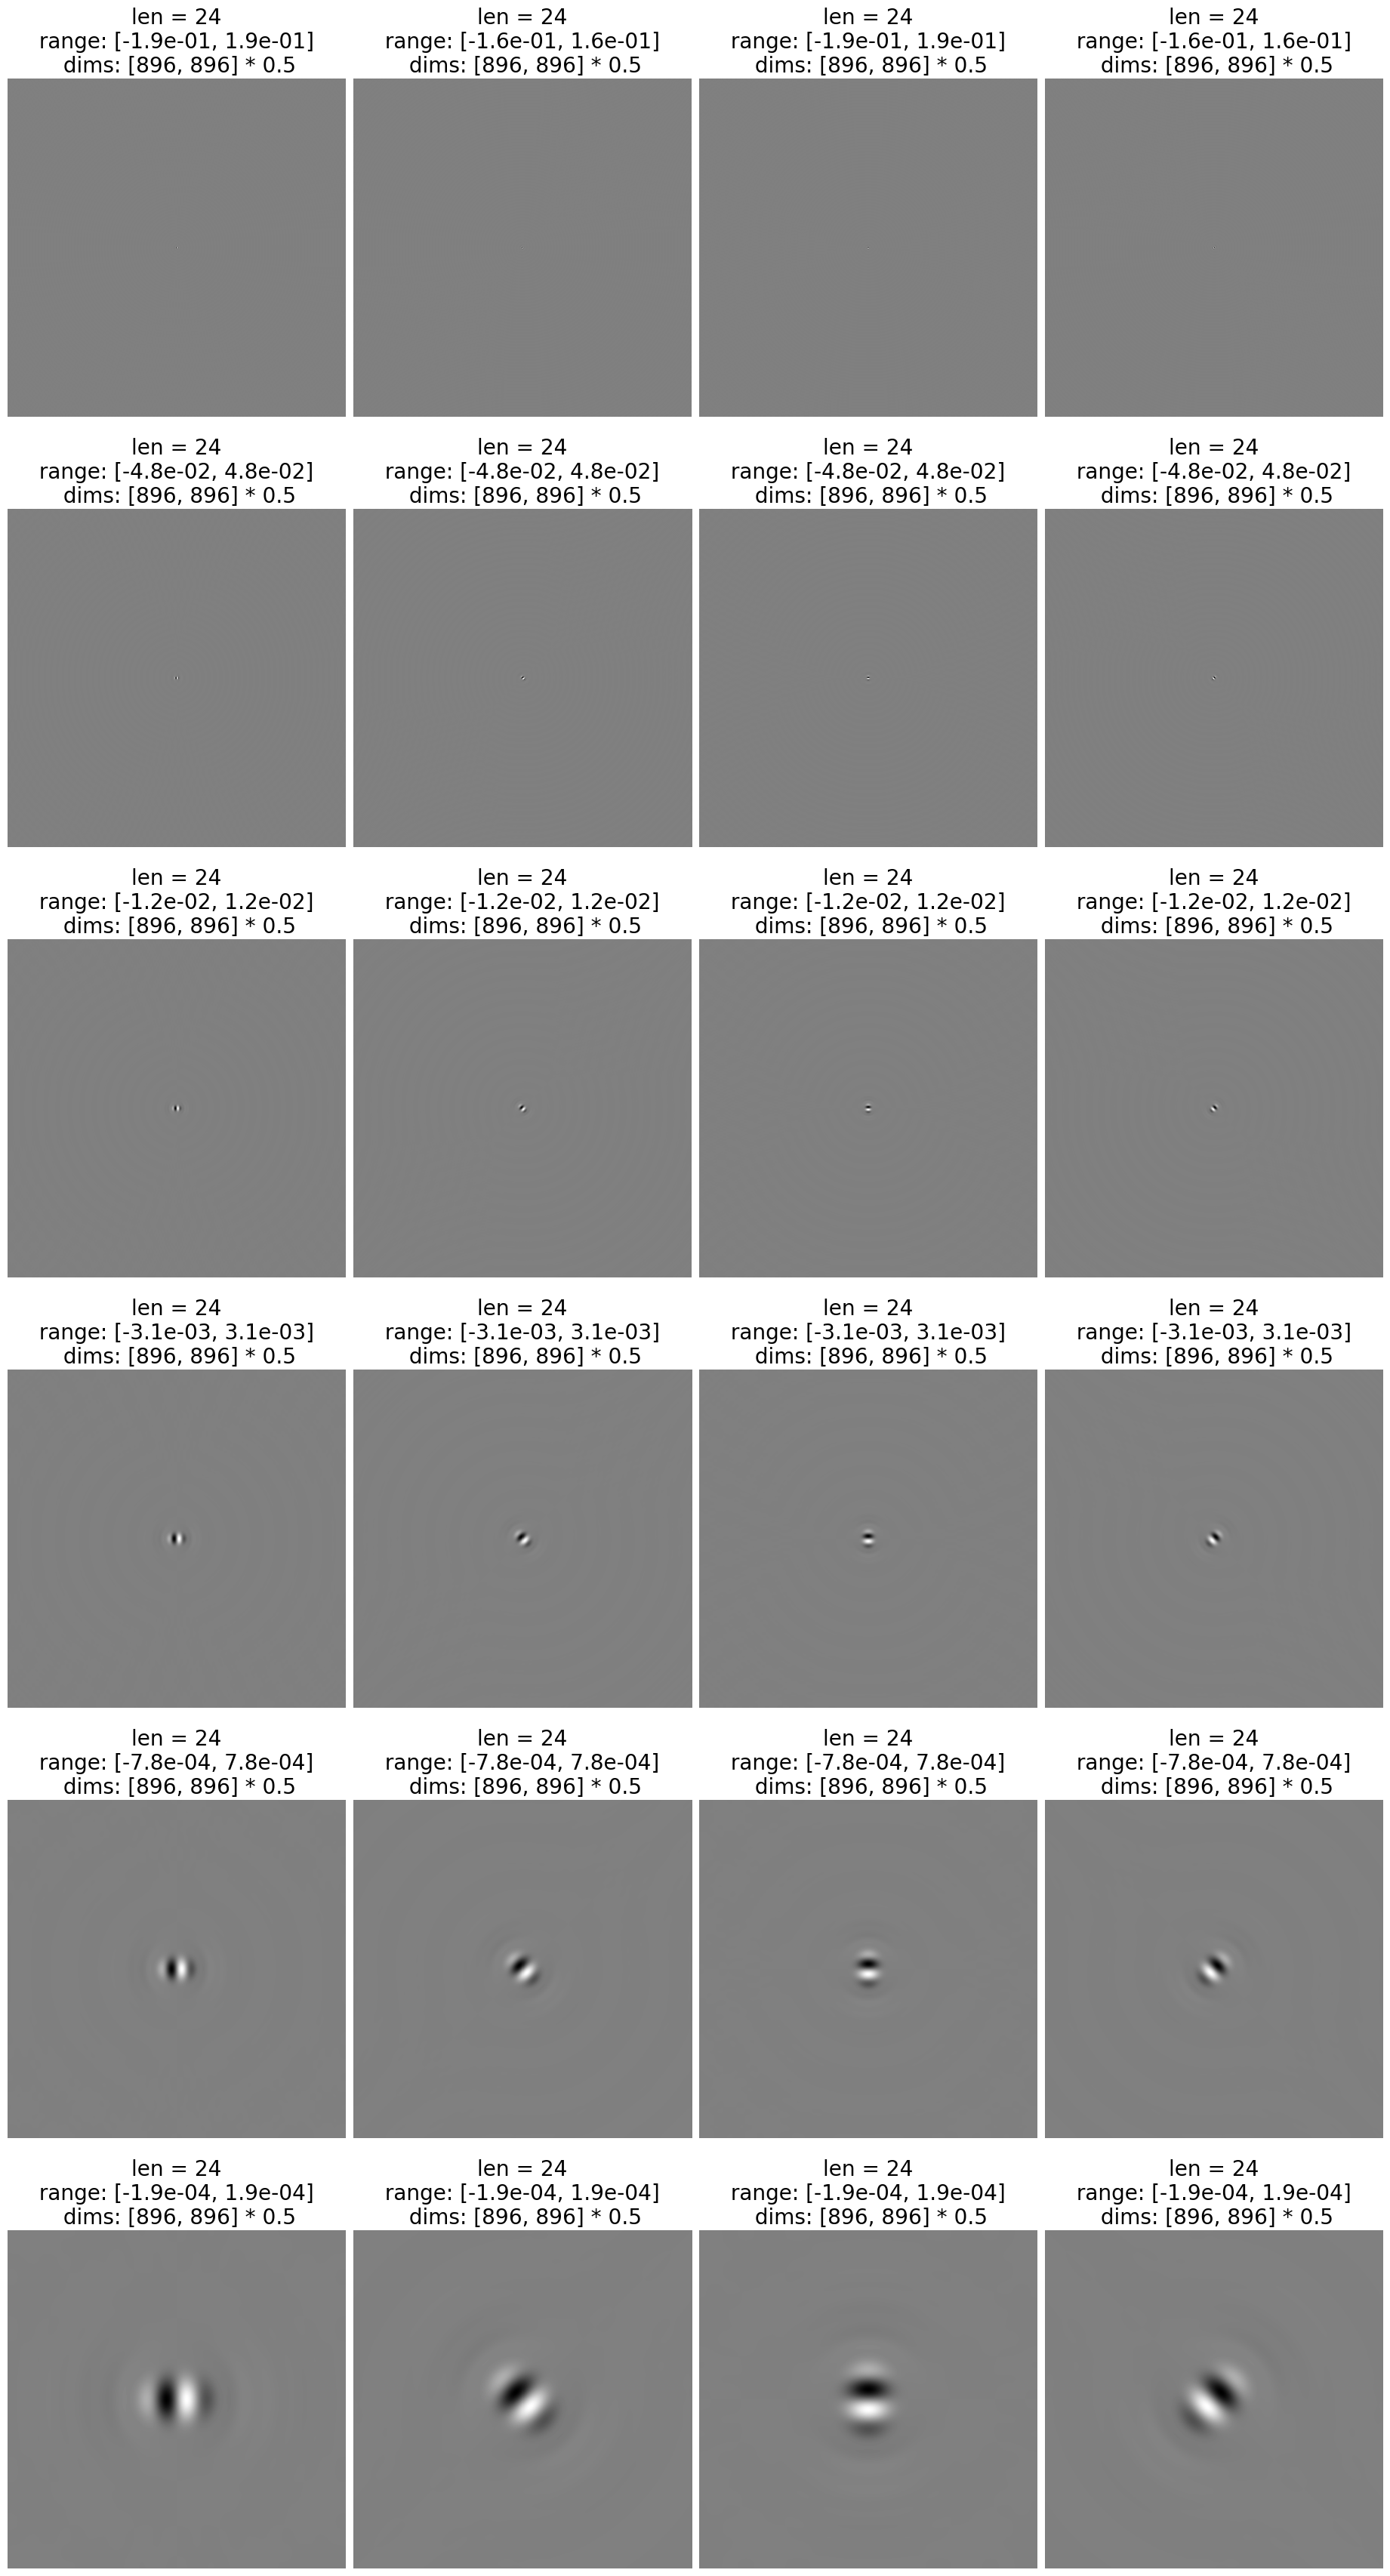

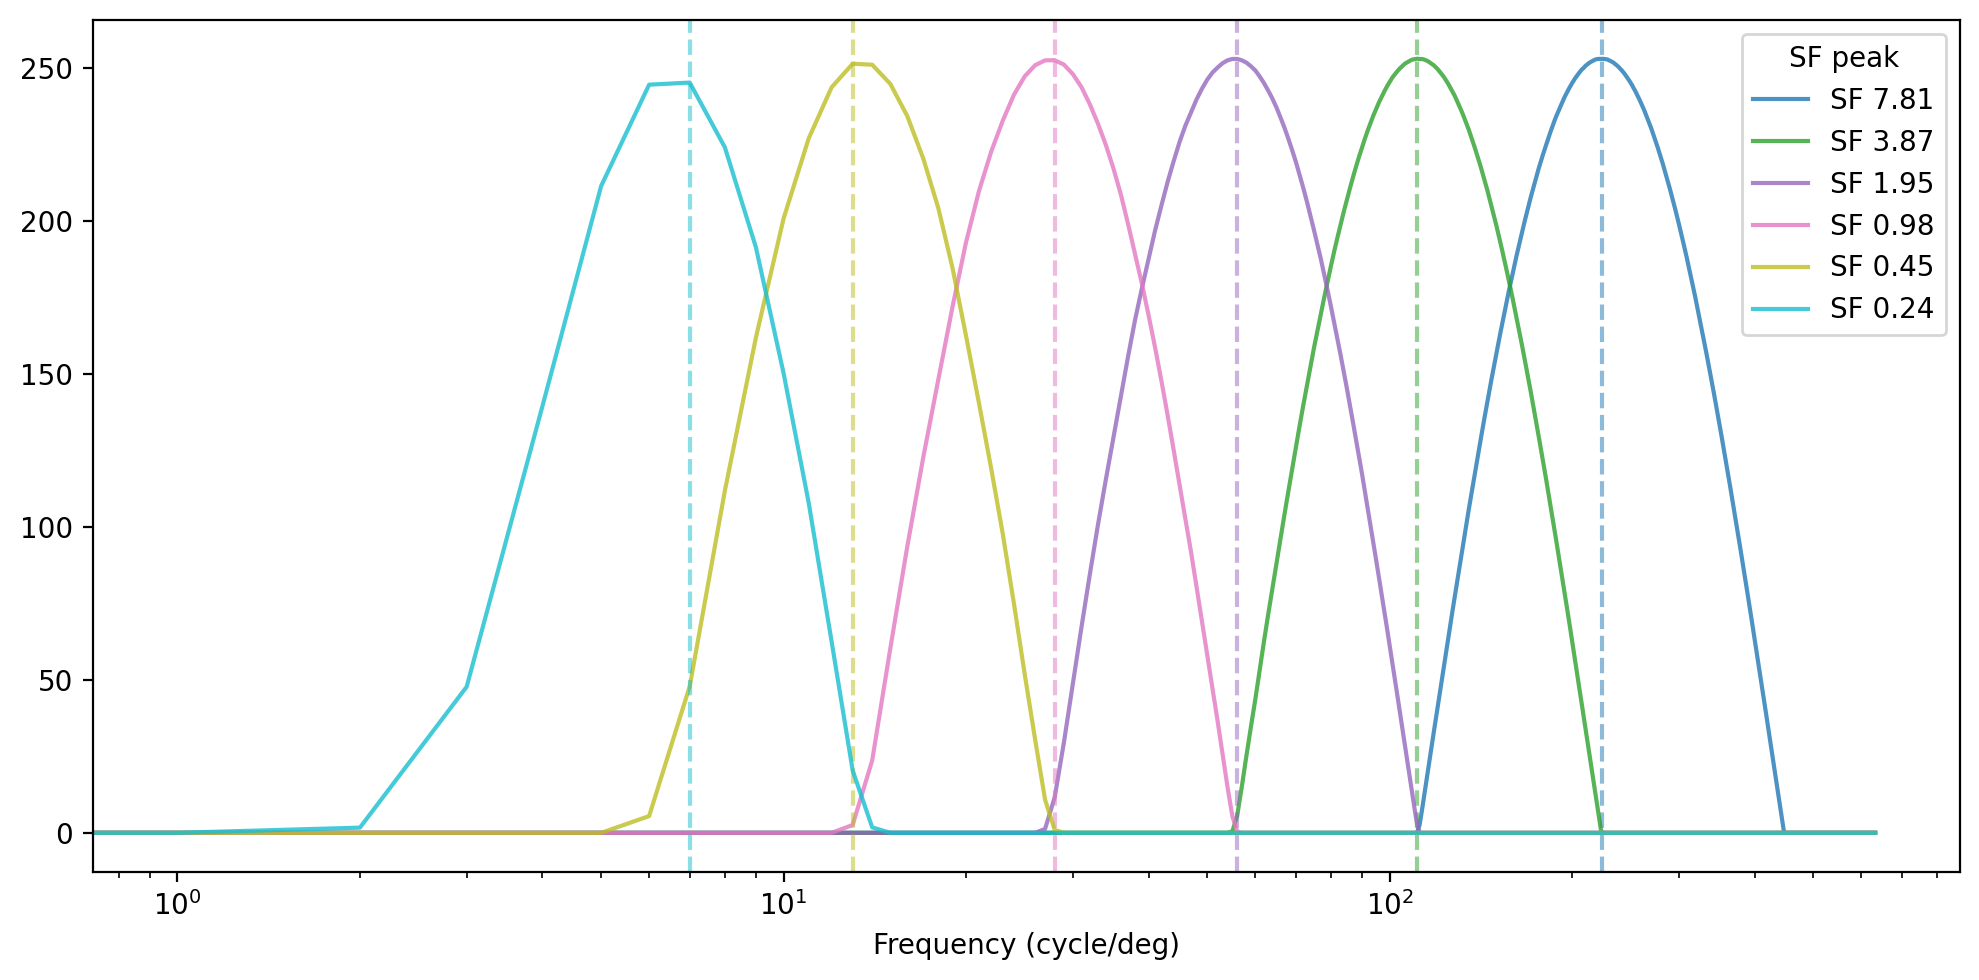

In [38]:
# this depends on img_size (.25, .125, 0.06, 0.03, 0.015, 0.006)
# also changes with n_sf (more low SF ch, and minimally with n_ori)

filter_sf_tunings = my_model.get_filter_sf_tunings()
colors = plt.cm.tab10(np.linspace(0, 1, n_sf))
fig, axes = plt.subplots(1, 1, figsize=(10, 5), dpi=200)
chSFs = {}
for i, sf in enumerate(range(n_sf)):
    k = np.where(filter_sf_tunings[sf] == filter_sf_tunings[sf].max())[0][0]
    chSFs[i] = np.round(k/my_model.img_degrees,2)
    axes.plot(range(filter_sf_tunings.shape[-1]), 
              filter_sf_tunings[sf], 
              alpha=0.8, 
              label=f'SF {np.round(k/my_model.img_degrees,2)}', 
              color=colors[sf])
    axes.axvline(k, color=colors[sf], linestyle='--', alpha=0.5)

axes.set_xlabel('Frequency (cycle/deg)')
current = axes.get_xticks()
axes.set_xticks(current)
new = current/my_model.img_degrees
axes.set_xticklabels(np.round(new,2))
axes.legend(title='SF peak', loc='best')
axes.set_xscale("log")   # for log axis
plt.tight_layout();


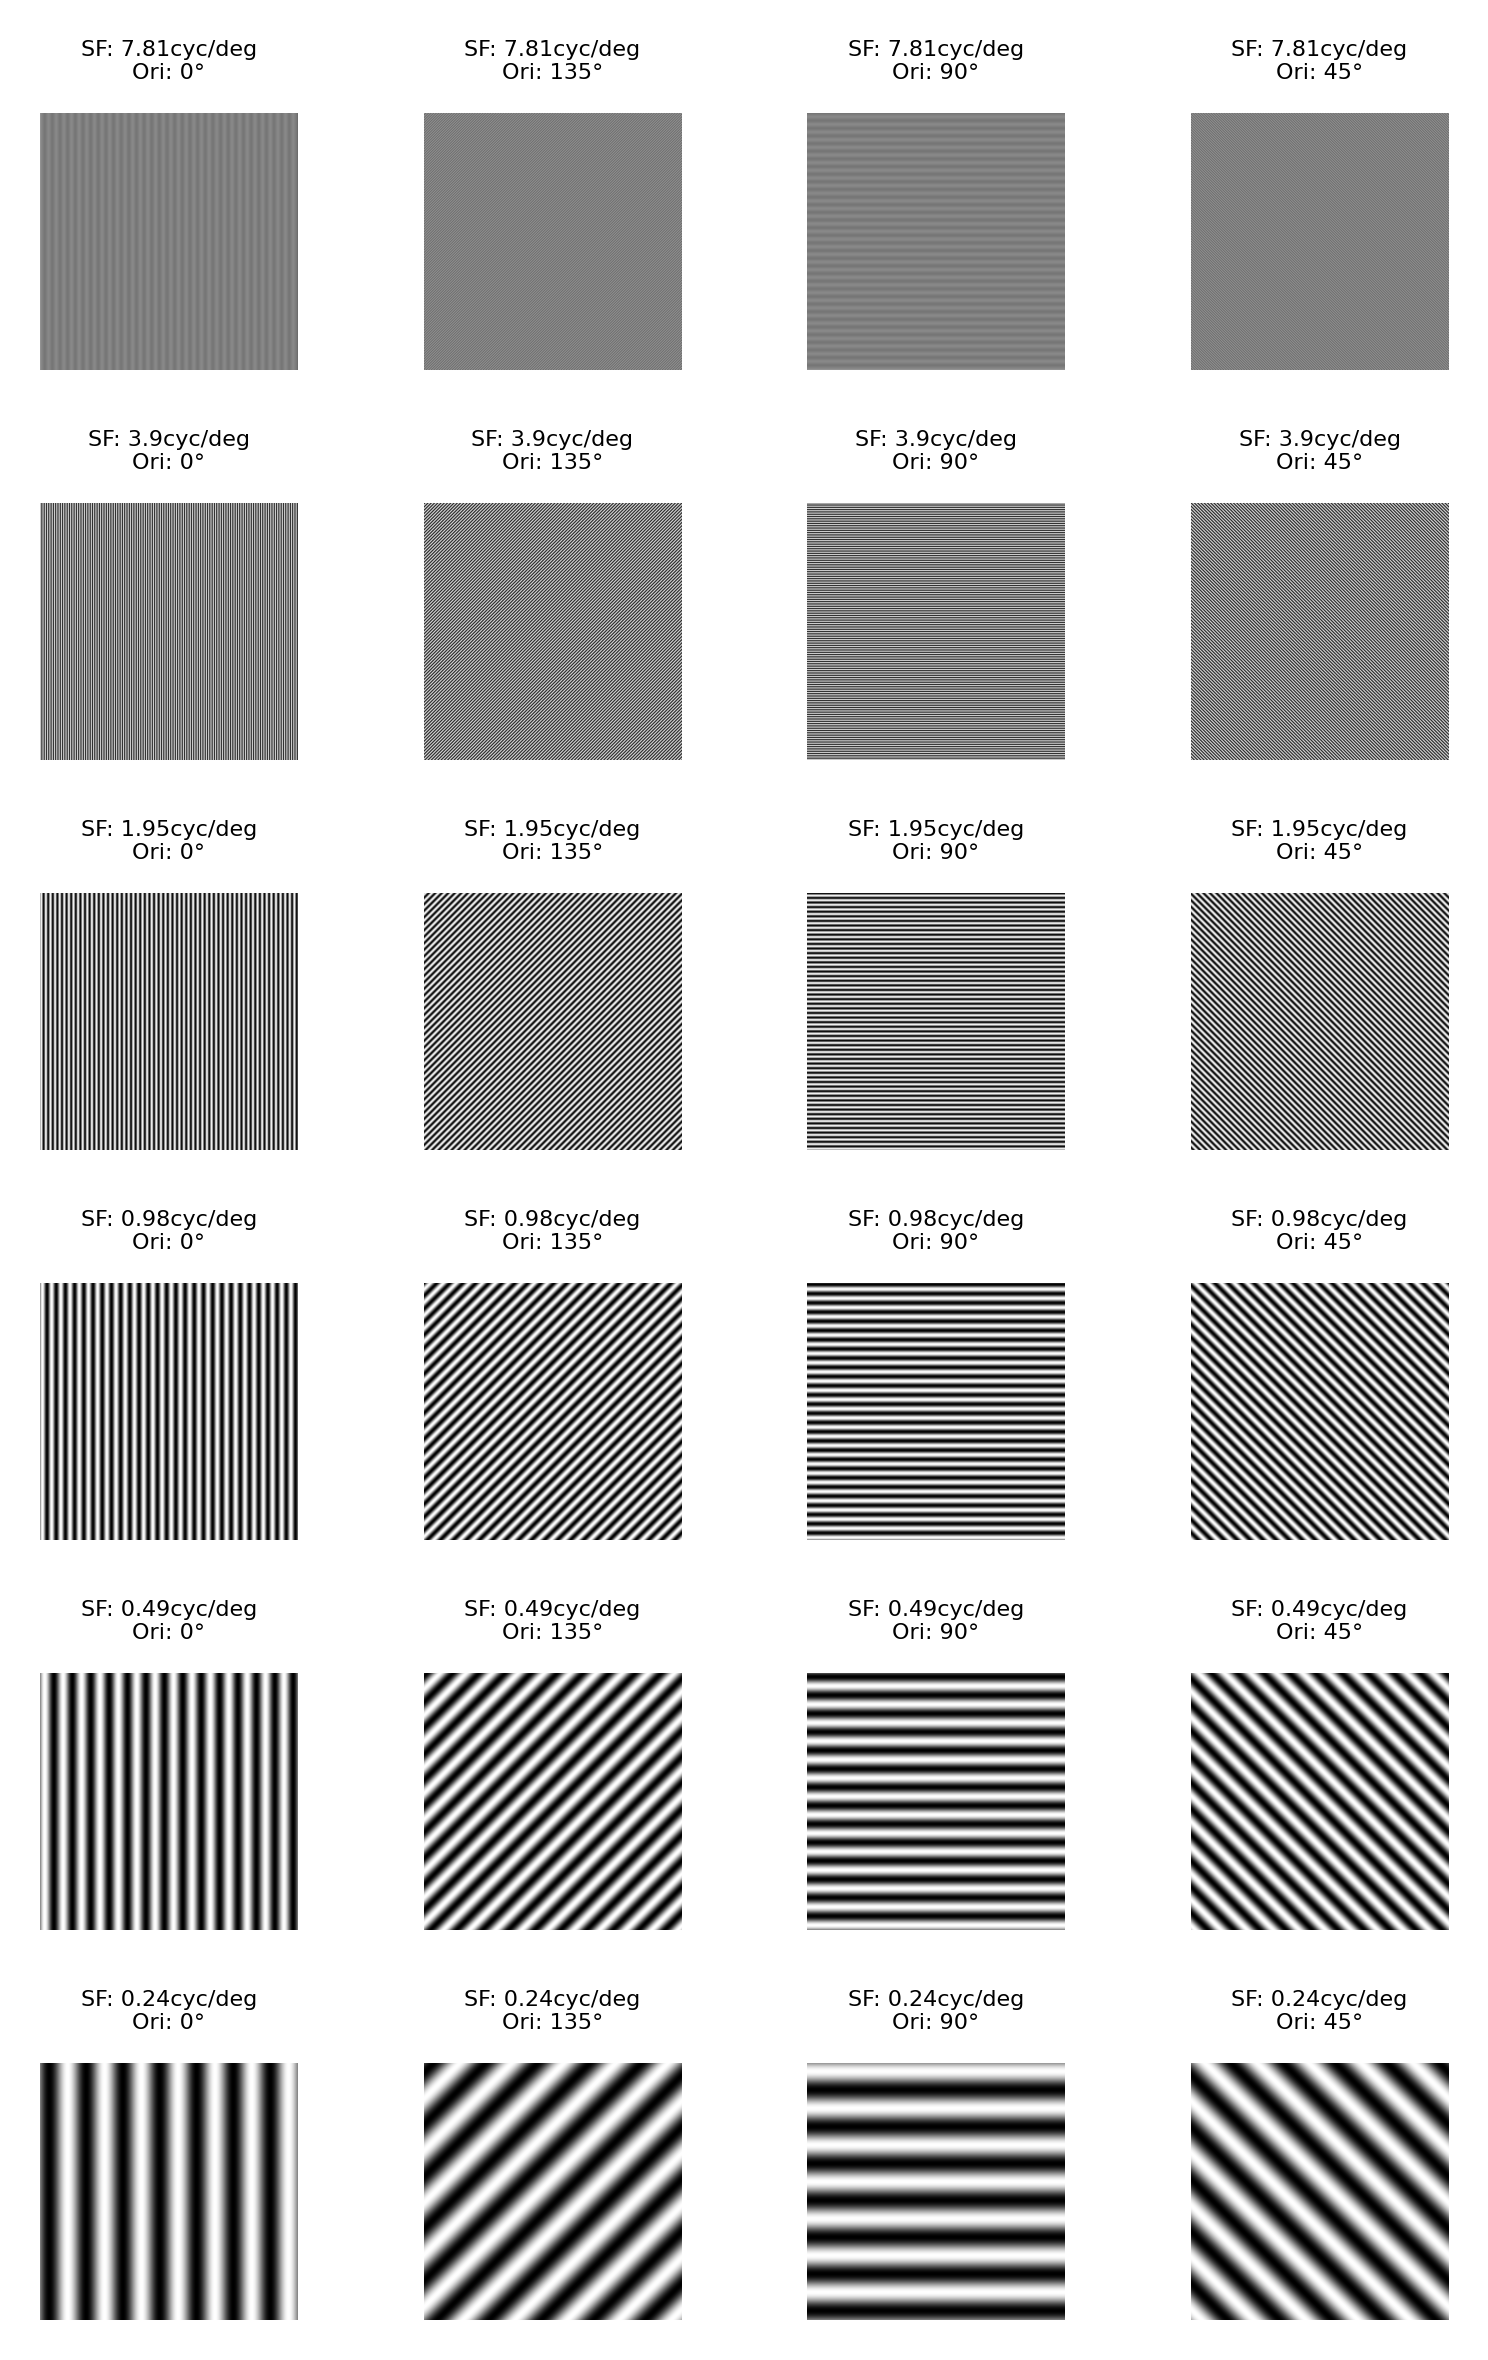

In [39]:
representative_chIdx = min(chSFs, key=lambda k: abs(chSFs[k] - 1)) # for later, this is idx closest to 1cyc/deg
optimal_stims = my_model.reconstruct_optimal_stimuli(visualize=True)

Cartesian grating SF (cycPP): 0.032020997375328084
Cartesian grating SF (cycPP): 0.032020997375328084
Cartesian grating SF (cycPP): 0.032020997375328084
Cartesian grating SF (cycPP): 0.032020997375328084
Polar grating SF (cycPP):
Tangential SF at half radius: 0.032021 cycles/pixel
Radial SF at half radius:     0.000000 cycles/pixel
Polar grating SF (cycPP):
Tangential SF at half radius: 0.022642 cycles/pixel
Radial SF at half radius:     0.022642 cycles/pixel
Polar grating SF (cycPP):
Tangential SF at half radius: 0.000000 cycles/pixel
Radial SF at half radius:     0.032021 cycles/pixel
Polar grating SF (cycPP):
Tangential SF at half radius: 0.022642 cycles/pixel
Radial SF at half radius:     0.022642 cycles/pixel


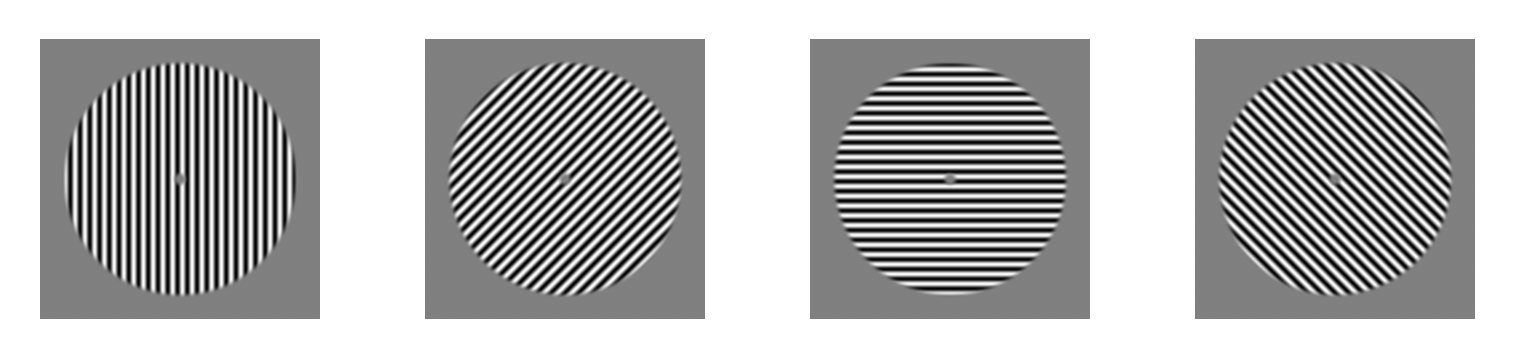

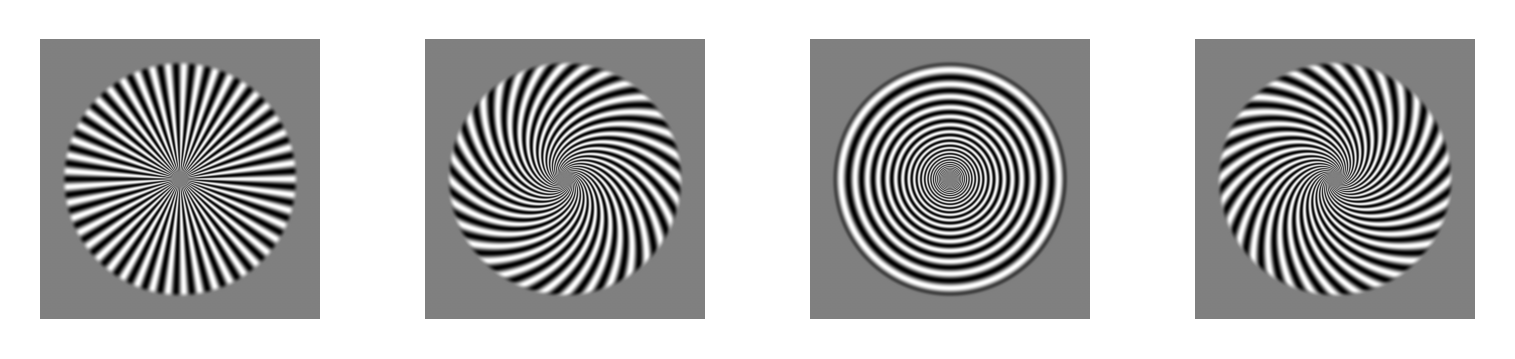

In [40]:
# Create input stimulus for the pyramid

sfs = np.array([1])               # cycles/deg
oris=np.array([0,135,90,45])      # degrees
stim = {}

for ri, ref in enumerate(["cartesian", "polar"]):
    stim[ri] = pyrmodel.InputStimuli(
        sfs=sfs,            
        oris=oris,
        img_size=img_size,
        img_degrees=padded_img_degrees,
        referenceframe=ref,
        mask=True,
        paddedBondaryPerc = exp_stim_diamDeg/padded_img_degrees
    )
    
    num_sf  = len(sfs)
    num_ori = len(oris)
    
    fig, axes = plt.subplots(num_sf, num_ori, figsize=(num_ori, num_sf), dpi=400)
    
    # force axes to always be 2D
    axes = np.atleast_2d(axes)
    
    for i, sf in enumerate(sfs):
        for j, ori in enumerate(oris):
            axes[i, j].imshow(stim[ri].input[i, j], cmap='gray', vmin=-1, vmax=1)
            axes[i, j].axis('off')
    plt.tight_layout()


In [41]:
# prepare stack of images to convert to tensor (preparing for pyramid)

# build numpy stack (dim0=set type, dim1=ori, dim2=X, dim3=Y)
arr = np.stack([
    np.stack([stim[i].input[(0,j)] for j in range(4)])
    for i in range(2)
])

input_tensor = torch.from_numpy(arr).float()
np.shape(input_tensor)

#po.imshow(input_tensor, batch_idx=0);
#po.imshow(input_tensor, batch_idx=1);

torch.Size([2, 4, 896, 896])

In [42]:
#type(input_tensor)

In [43]:
dim_im = img_size

# NOTE: kept off MPS regardless of DEVICE -- this pyramid uses complex-valued
# FFTs internally (is_complex=True), and PyTorch's MPS backend doesn't support
# complex dtypes for FFT ops as of torch 2.2.2 (same limitation as the main
# pyramid in the cell above). input_tensor must move with it, or you'd hit a
# "tensors on different devices" error instead.
pyr_device = torch.device('cpu') if DEVICE.type == 'mps' else DEVICE

# build a steerable pyramid object
pyr = SteerablePyramidFreq(height=n_sf, 
                           image_shape=[dim_im, dim_im], 
                           order=3, is_complex=True,
                           tight_frame=True).to(
                           pyr_device
                           )

# pass the Tensor into the object
stim_coeffs = pyr(input_tensor.to(pyr_device))      # pass these stim inputs into pyramid

#stim_coeffs = my_model.forward(input_tensor)
print(stim_coeffs.keys())

# display output image per stimulus per channel
#po.pyrshow(stim_coeffs, vrange='auto1', zoom=1, batch_idx=2) # first image of the batch (cartesian)
#po.pyrshow(stim_coeffs, vrange='auto1', zoom=1, batch_idx=1); # second image of the batch (polar)

odict_keys(['residual_highpass', (0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (2, 3), (3, 0), (3, 1), (3, 2), (3, 3), (4, 0), (4, 1), (4, 2), (4, 3), (5, 0), (5, 1), (5, 2), (5, 3), 'residual_lowpass'])


In [44]:
all_data = []  # to store (sf, ori, batch, channel, energy_value)

for key, tensor in stim_coeffs.items():
    if isinstance(key, tuple):
        sf, ori = key
        for b in range(tensor.shape[0]):      # batch index
            for c in range(tensor.shape[1]):  # channel index
                img = tensor[b, c].abs() ** 2
                energy_value = img.mean().item()   # or .sum().item(), depending on what you want
                all_data.append([sf, ori, b, c, energy_value])
    else:
        continue  # skip residuals

# Convert list → NumPy array
all_data = np.array(all_data)  # shape [N, 5], columns = [sf, ori, batch, channel, energy]


In [45]:
#all_data[:,1]

In [46]:
#representative_chIdx

# ordered dictionary
#odict_keys(['residual_highpass', 
#(0, 0), (0, 1), (0, 2), (0, 3), 
#(1, 0), (1, 1), (1, 2), (1, 3), 
#(2, 0), (2, 1), (2, 2), (2, 3), 
#(3, 0), (3, 1), (3, 2), (3, 3), <----
#(4, 0), (4, 1), (4, 2), (4, 3), 
#(5, 0), (5, 1), (5, 2), (5, 3), 
#'residual_lowpass'])

# tmp = my_model.get_energy_of_filters(stim_coeffs, 
#                                          to_magnitude=True, 
#                                          to_numpy=True, 
#                                          reshape=True, 
#                                          normalize=False)

# for key, arr in stim_energy.items():
#     print(key, arr.shape)

Plot output of pyramid, with balanced ori channels
BALANCED PYRAMID OUTPUT
no scale given, so computing shared scale: global min/max


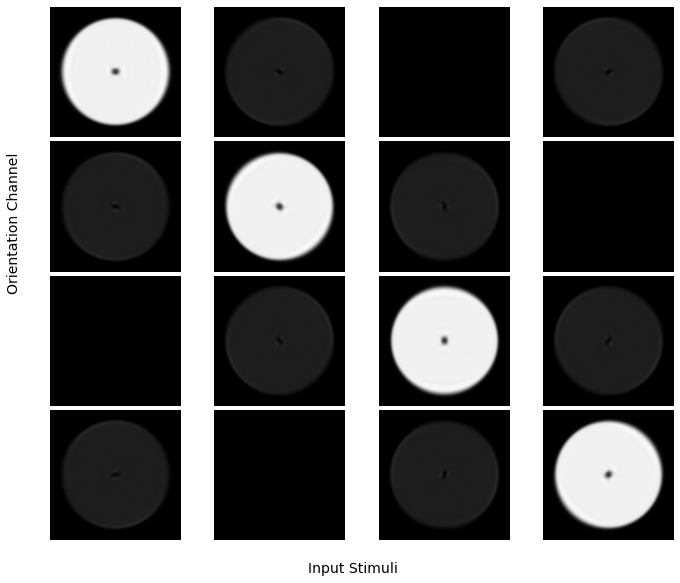

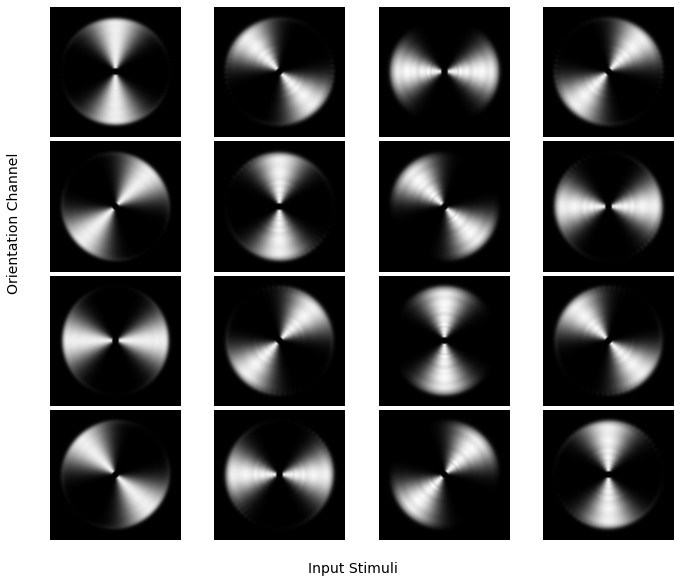

(6.952972482389964e-18, 0.0707826449577927)

In [47]:
np.shape(input_tensor)

print('Plot output of pyramid, with balanced ori channels')

stim_energy = {}
n_set = 2
n_stimuli = 4

for i, j in product(range(n_set), range(n_stimuli)):
    stim_coeffs = my_model.forward(input_tensor[i, j, :, :])
    energy = my_model.get_energy_of_filters(stim_coeffs,
                                            to_magnitude=False,  # compute energy, rather than mag (just squaring)
                                            to_numpy=True,
                                            reshape=True,
                                            normalize=False)    # do not need to do this, due to tight pyramid?
    stim_energy[(i, j)] = energy

# my_model.visualize_filter_magnitudes(stim_energy, 
#                                      share_color_range=True, 
#                                      title='Optimal Stimuli E')


print("BALANCED PYRAMID OUTPUT")
stim_energy_aveSF = utils_image.condense_energy(stim_energy, dim=0, operation="mean")

utils_image.visualize_filter_magnitudes(stim_energy_aveSF, 0, scale=None, share_color_range=True, title=None,
                                        cbar=False, scale_factor=3, save_path=None)
#[scaleMin, scaleMax]

#utils_image.plot_energy_per_channel(stim_energy_aveSF, 0, pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[-.1, 0.15])

#utils_image.plot_energy_per_stim(stim_energy_aveSF, 0, "Cartesian analysis", pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 0.15])

#utils_image.plot_energy_per_stim(stim_energy_aveSF, 0, "Polar analysis", pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 0.15])


IMBALANCED PYRAMID OUTPUT
no scale given, so computing shared scale: global min/max


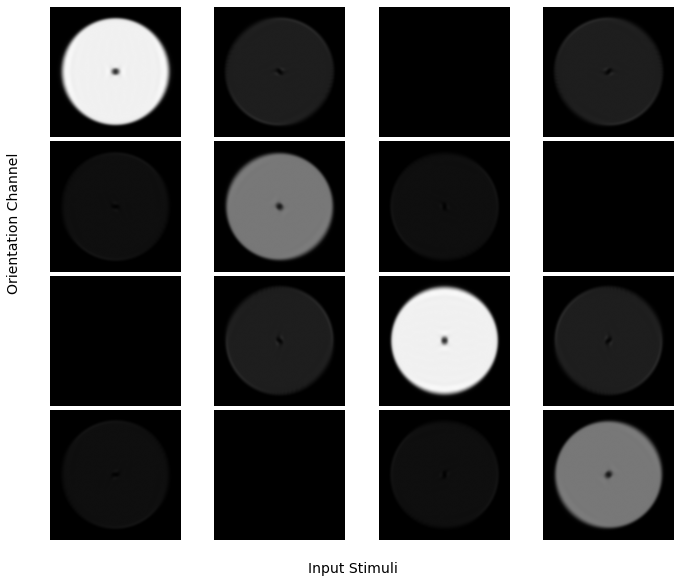

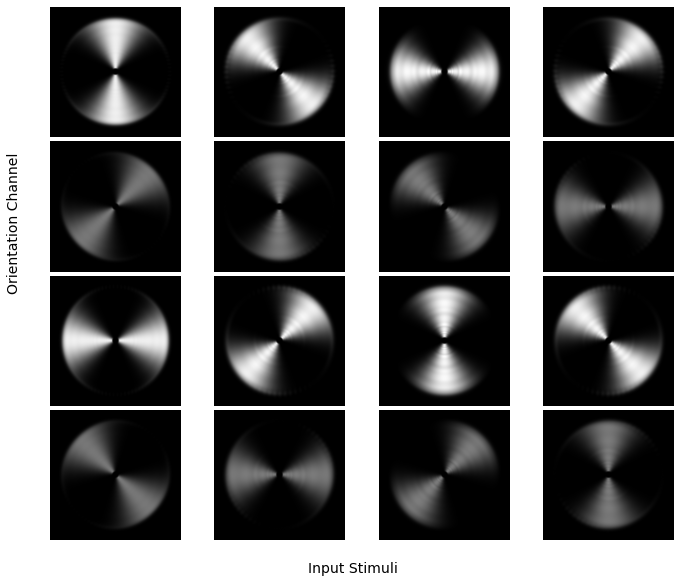

(6.952972482389964e-18, 0.1415251315408265)

In [48]:
# create imbalanced population for a given channel

print("IMBALANCED PYRAMID OUTPUT")
# based on Fang et al 2022 -- The cardinal and radial components modulated 10.90% and 14.83%, respectively. (In macaque V1)
# based on behavior, 1.3 and 1.1
stim_energy_imb = utils_image.imposeImbalance(stim_energy, cardinal=2, radial=1)

stim_energy_imb_aveSF = utils_image.condense_energy(stim_energy_imb, dim=0, operation="mean")

utils_image.visualize_filter_magnitudes(stim_energy_imb_aveSF, 0, scale=None, share_color_range=True, title=None,
                                        cbar=False, scale_factor=3, save_path=None)

#utils_image.plot_energy_per_channel(stim_energy_imb_aveSF, 0, pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[-0.1, 0.15])

#utils_image.plot_energy_per_stim(stim_energy_imb_aveSF, 0, "Cartesian analysis", pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 0.15])

#utils_image.plot_energy_per_stim(stim_energy_imb_aveSF, 0, "Polar analysis", pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 0.15])

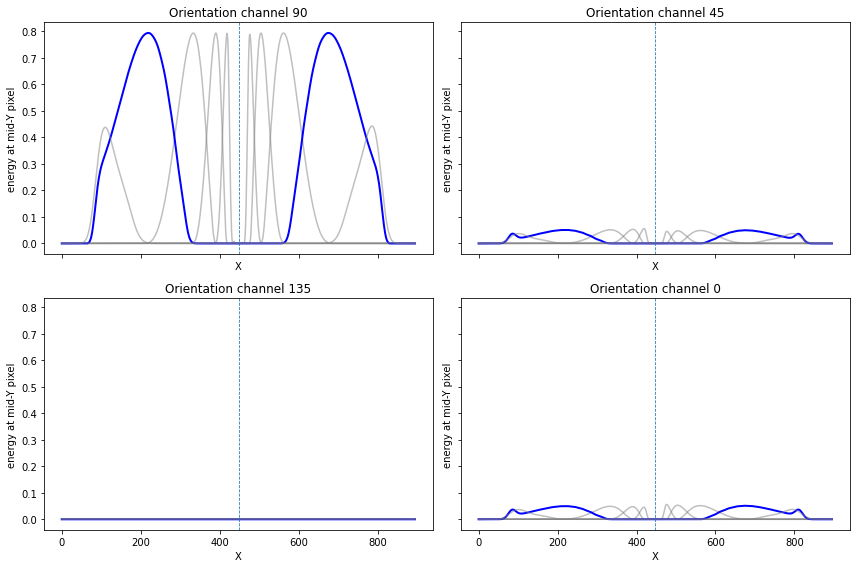

In [49]:
setIdx=1
stimIdx=0
oriChNames = [90, 45, 135, 0]
arr = stim_energy_imb[setIdx,stimIdx] # set , stimulus
                       #  set = 0        # 1-vertical
                       # set = 1         # 2-pinwheel

y_idx = 448
n_sf, n_ori, n_x, n_y = arr.shape

highlight_sf = 3  # 4th SF (0-indexed)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ori in range(n_ori):
    ax = axes[ori]
    
    for sf in range(n_sf):
        curve = arr[sf, ori, :, y_idx]
        
        if sf == highlight_sf:
            ax.plot(np.arange(n_x), curve, color='blue', linewidth=2, label=f"SF {sf} (highlight)")
        else:
            ax.plot(np.arange(n_x), curve, color='gray', alpha=0.5)
    
    ax.set_title(f"Orientation channel {oriChNames[ori]}")
    ax.set_xlabel("X")
    ax.set_ylabel("energy at mid-Y pixel")
    ax.axvline(x=n_x // 2, linestyle="--", linewidth=0.8)

# legend only for highlighted line
handles, labels = axes[0].get_legend_handles_labels()
#fig.legend(handles, labels, loc="upper right")

fig.tight_layout()
plt.show()

In [50]:
# untuned divisive normalization

# # sum across the SF dimension:

# # stim_energy_imb_summedSF = {
# #     key: np.sum(val, axis=0, keepdims=True)
# #     for key, val in stim_energy_imb.items()
# # }

# # untuned_norm_energy = utils_image.canonical_normalization(stim_energy_imb_summedSF, pixpdeg, representative_chIdx=0, tuned=False)

# # or keep it isolated to SF of interest
# #stim_energy_imb_selectSF = stim_energy_imb

# stim_energy_imb_selectSF = {
#     key: arr[3:4, ...]     # slice keeps shape (1, 4, 896, 896)
#     for key, arr in stim_energy_imb.items()
# }

# # to run on select SF channel
# #untuned_norm_energy = utils_image.canonical_normalization(stim_energy_imb_selectSF, pixpdeg, representative_chIdx=0, tuned=False)

print("UNTUNED DIVISIVE NORMALIZATION")
## run untuned divisive normalization, then average across SF channels

untuned_norm_energy = utils_image.div_normalization(stim_energy_imb, pixpdeg, tuned=False)

untuned_norm_energy_aveSF = utils_image.condense_energy(untuned_norm_energy, dim=0, operation="mean")


UNTUNED DIVISIVE NORMALIZATION
k1: sf=93.68852459016394 (octaves-equiv), ori=93.68852459016394 (radians-equiv), x=93.68852459016394px, y=93.68852459016394px | k2: sf=0, ori=0, xy=0.032021 deg (1.0px)


no scale given, so computing shared scale: global min/max


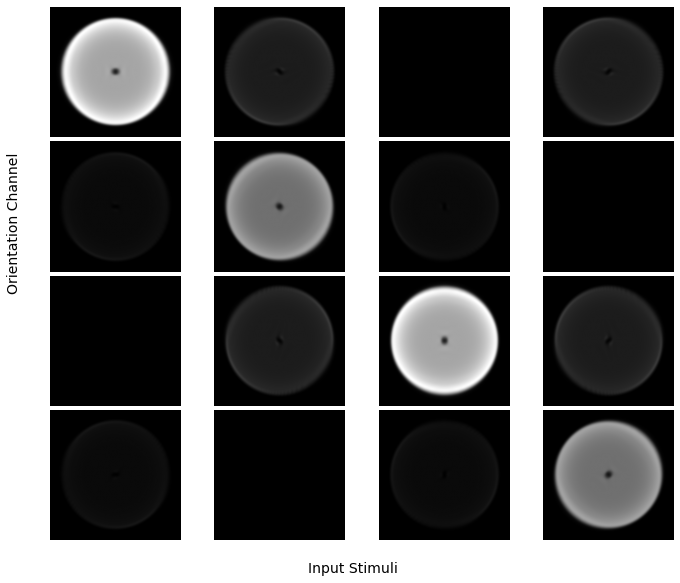

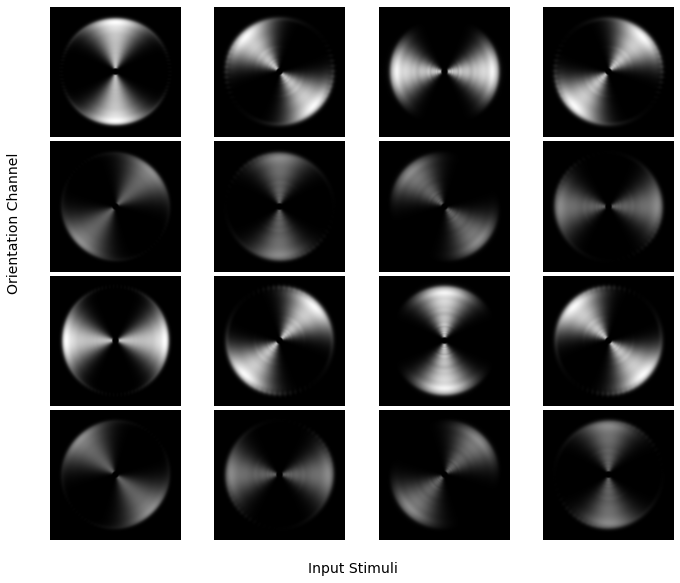

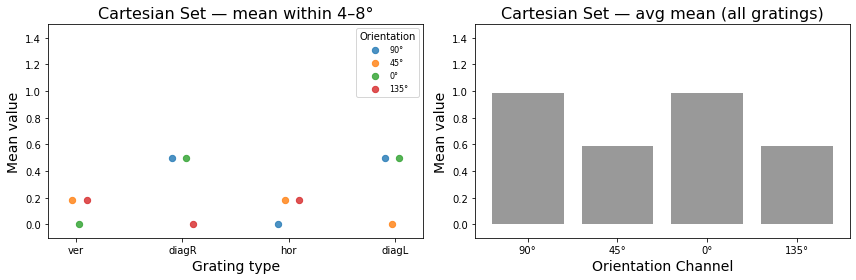

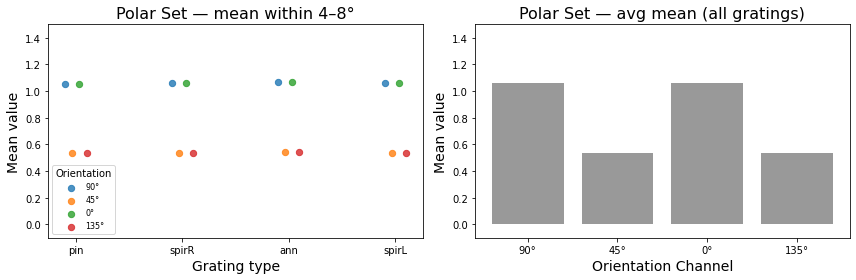

Cartesian Set
['ver', 'diagR', 'hor', 'diagL']
[3.326961470666003, 2.9889755116369296, 3.326961142914284, 2.988973156026311]


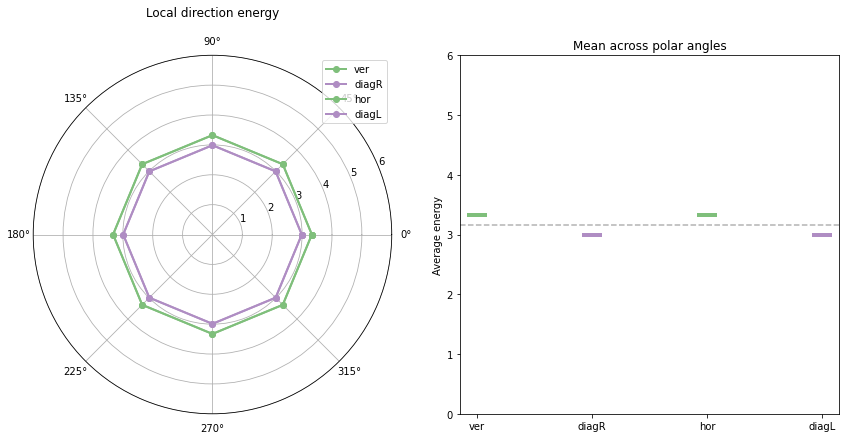

Polar Set
['ver', 'diagR', 'hor', 'diagL']
[3.5488447037171014, 2.844444399766467, 3.5488521143629703, 2.8444642009617302]


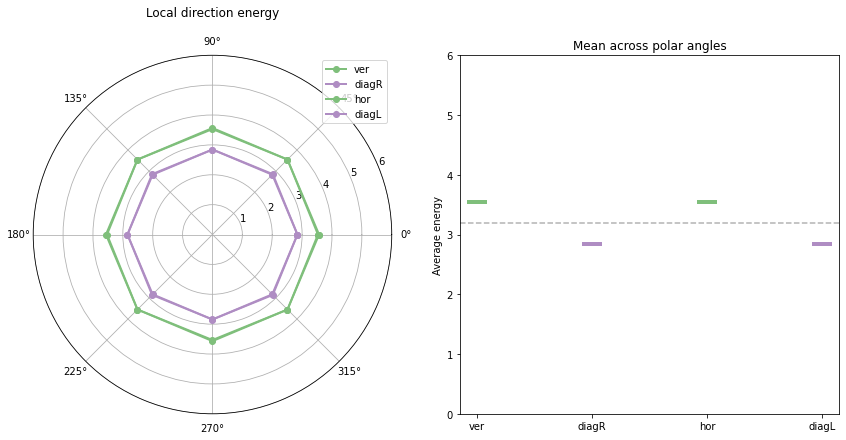

1.2249502399101944
------------------------------------------------------------
Cartesian Set
['pin', 'spirR', 'ann', 'spirL']
[3.1571580725581834, 3.1581153645442837, 3.1584824759829564, 3.1581153681581036]


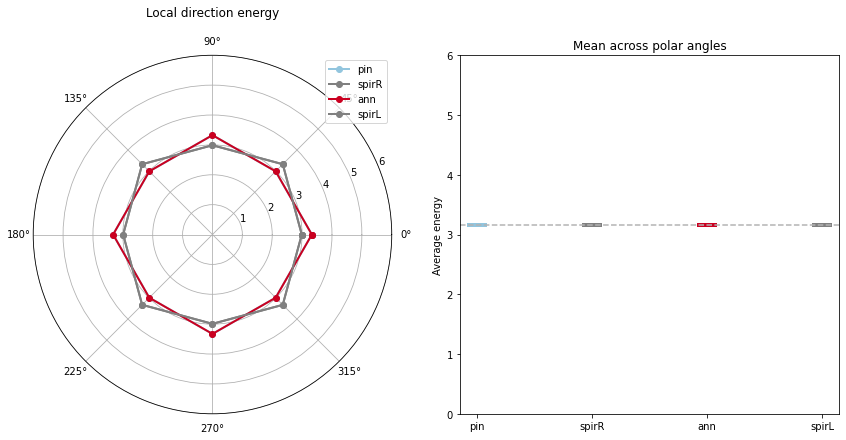

Polar Set
['pin', 'spirR', 'ann', 'spirL']
[3.180589059560829, 3.197099783804457, 3.211816576806008, 3.1970999986369746]


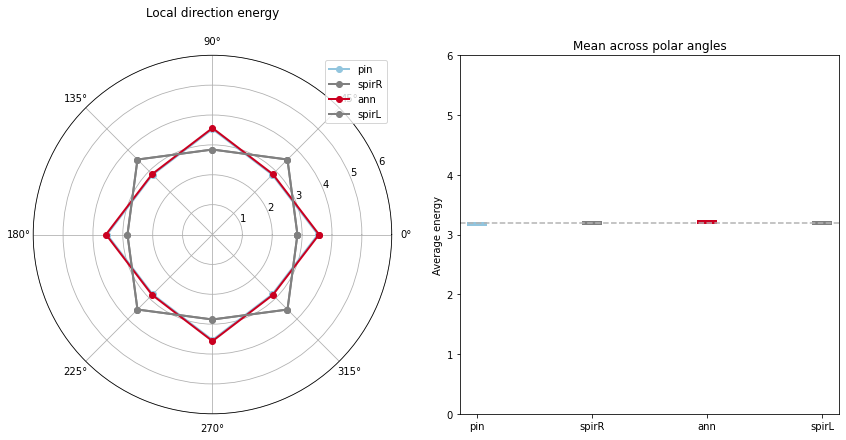

([['pin', 'spirR', 'ann', 'spirL'], ['pin', 'spirR', 'ann', 'spirL']],
 [[3.1571580725581834,
   3.1581153645442837,
   3.1584824759829564,
   3.1581153681581036],
  [3.180589059560829,
   3.197099783804457,
   3.211816576806008,
   3.1970999986369746]])

In [51]:
## visualize

utils_image.visualize_filter_magnitudes(untuned_norm_energy_aveSF, 0, scale=None, share_color_range=True, title=None,
                                        cbar=False, scale_factor=3, save_path=None)

utils_image.plot_energy_per_channel(untuned_norm_energy_aveSF, 0, pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[-.1, 1.5]) #1.4])

[a,b] = utils_image.plot_energy_per_stim(untuned_norm_energy_aveSF, 0, "Cartesian analysis", pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 6])
b = np.array(b)
mm = b.mean(axis=1)
percent_increase = (mm[1] - mm[0]) / mm[0] * 100
print(percent_increase)
print('------------------------------------------------------------')

utils_image.plot_energy_per_stim(untuned_norm_energy_aveSF, 0, "Polar analysis", pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 6])



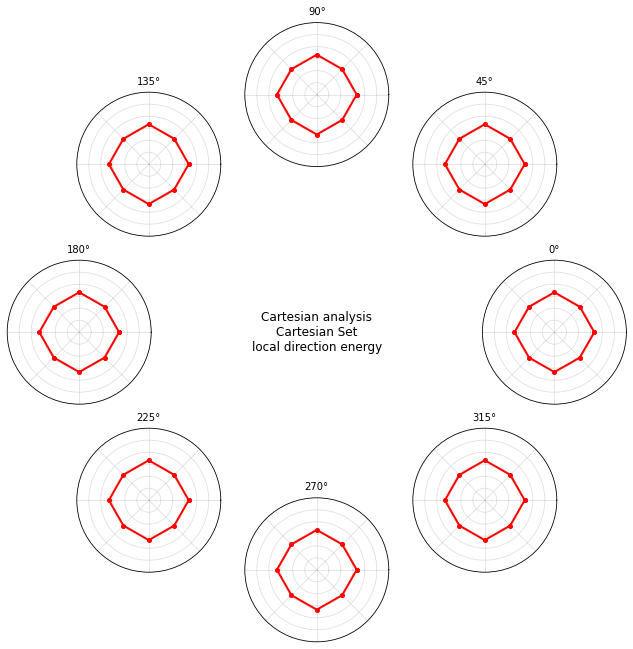

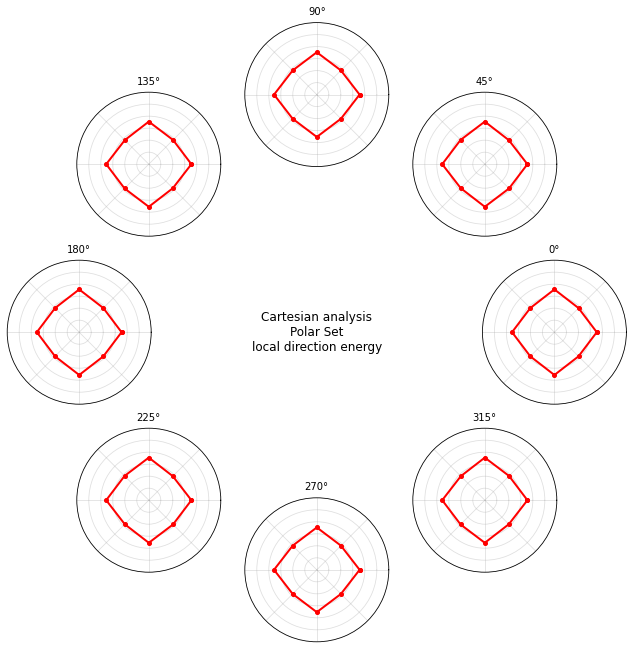

In [52]:
utils_image.plot_energy_per_location_polar(untuned_norm_energy_aveSF, 0, "Cartesian analysis",
                                   pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 6])

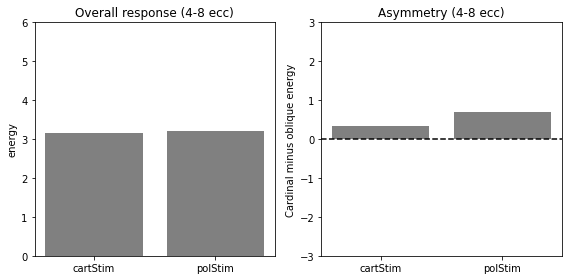

In [53]:
# plot the asymmetry relative to the mean # plot the mean for each stimulus set

def plot_quickView(b):
    b = np.array(b)
    
    # --- subplot 1: means ---
    means = b.mean(axis=1)

    ymean = round(np.mean(means))
    
    # --- subplot 2: differences ---
    # (0 - 1) and (2 - 3) averaged per row
    diffs = np.array([
        (row[0] - row[1] + row[2] - row[3]) / 2
        for row in b
    ])
    
    # plotting
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    
    # subplot 1
    axes[0].bar([0, 1], means, color='gray')
    axes[0].set_title('Overall response (4-8 ecc)')
    axes[0].set_ylabel("energy")
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(['cartStim', 'polStim'])
    axes[0].set_ylim([0, ymean*2])
    
    # subplot 2
    axes[1].bar([0, 1], diffs, color='gray')
    axes[1].set_title('Asymmetry (4-8 ecc)')
    axes[1].set_ylabel("Cardinal minus oblique energy")
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(['cartStim', 'polStim'])
    axes[1].set_ylim([-ymean, ymean])
    axes[1].axhline(0, linestyle='--', color='black')
    
    plt.tight_layout()
    plt.show()

plot_quickView(b)

In [54]:
# exponential suppression
print("UNTUNED DIVISIVE NORMALIZATION -- with EXPONENTIAL SUPPRESSION")

expDen_norm_energy = utils_image.div_normalization(stim_energy_imb, pixpdeg, q_exp = 2, tuned=False)

expDen_norm_energy_aveSF = utils_image.condense_energy(expDen_norm_energy, dim=0, operation="mean")



UNTUNED DIVISIVE NORMALIZATION -- with EXPONENTIAL SUPPRESSION
k1: sf=93.68852459016394 (octaves-equiv), ori=93.68852459016394 (radians-equiv), x=93.68852459016394px, y=93.68852459016394px | k2: sf=0, ori=0, xy=0.032021 deg (1.0px)


no scale given, so computing shared scale: global min/max


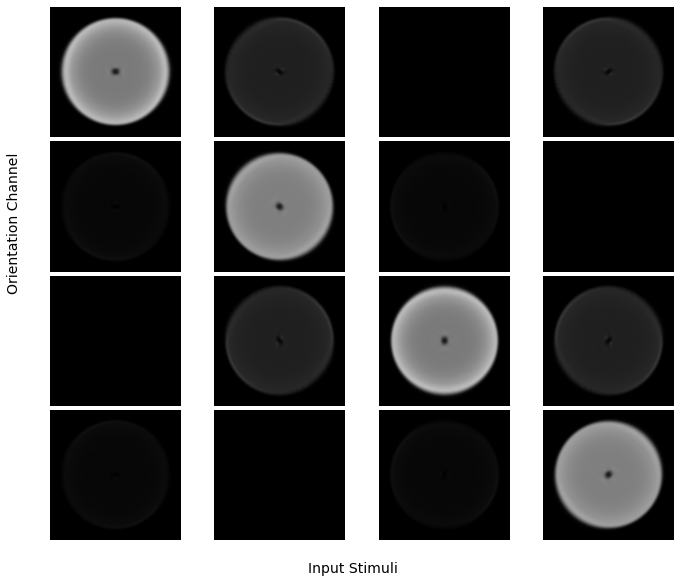

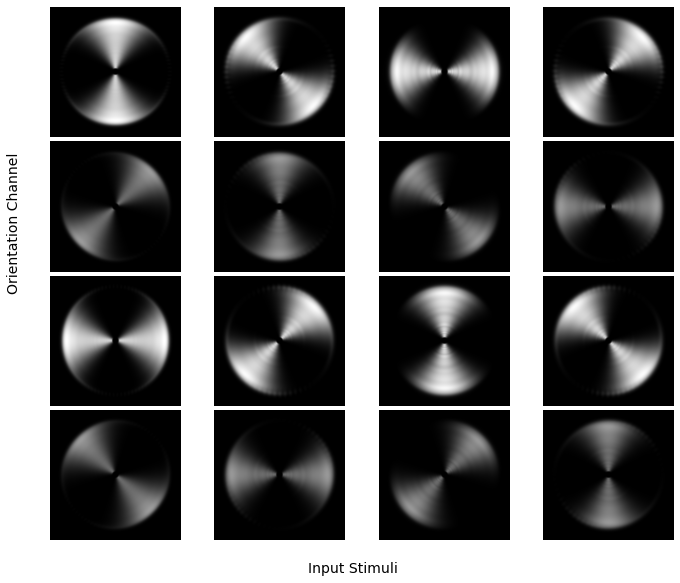

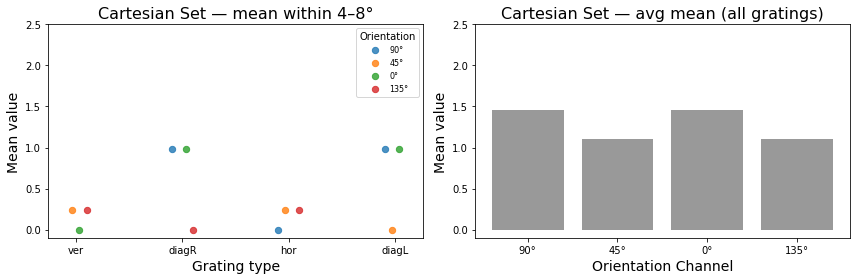

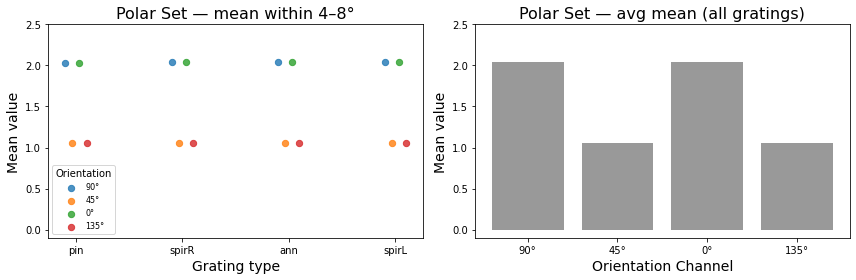

Cartesian Set
['ver', 'diagR', 'hor', 'diagL']
[4.33092853723127, 5.920657040692614, 4.330927685209387, 5.9206561163022435]


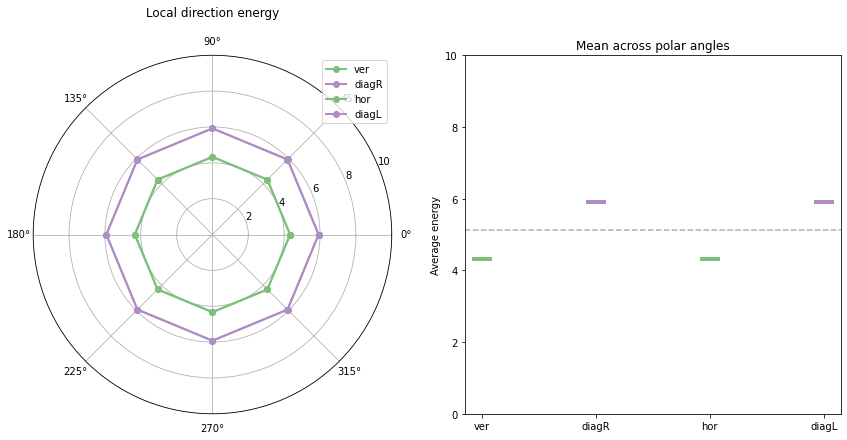

Polar Set
['ver', 'diagR', 'hor', 'diagL']
[6.755434175661024, 5.613716563566752, 6.755441515112713, 5.61373719612047]


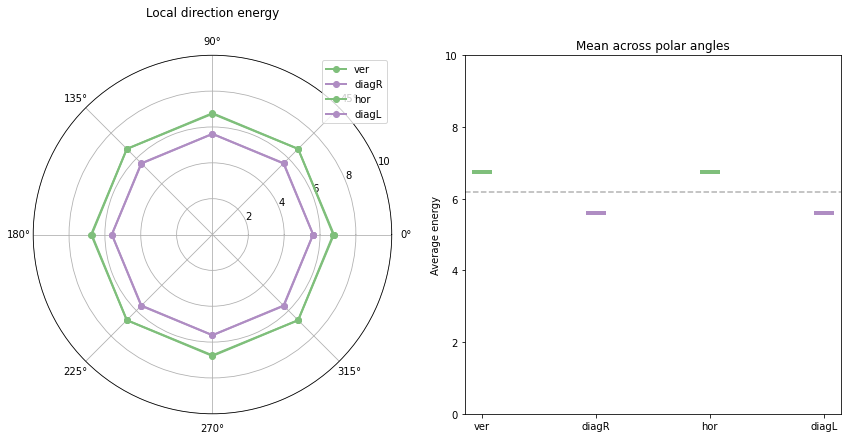

Cartesian Set
['pin', 'spirR', 'ann', 'spirL']
[5.119766532545933, 5.126074781421776, 5.131253267665329, 5.1260747978024765]


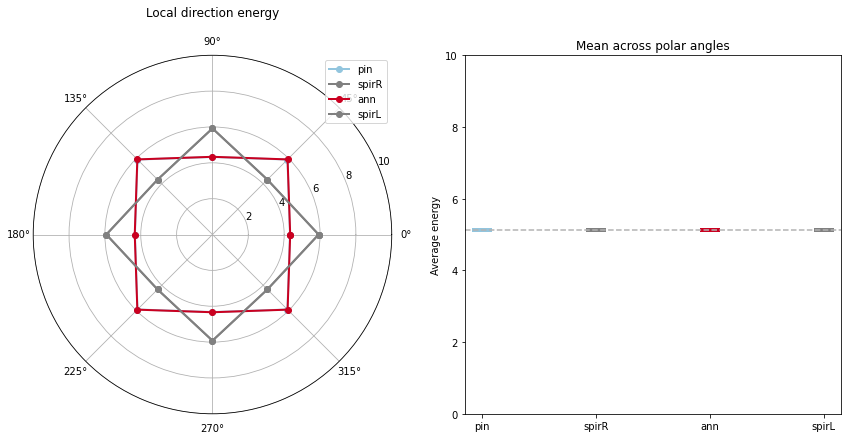

Polar Set
['pin', 'spirR', 'ann', 'spirL']
[6.1704144053652215, 6.185417708490914, 6.197079789846587, 6.185417546758234]


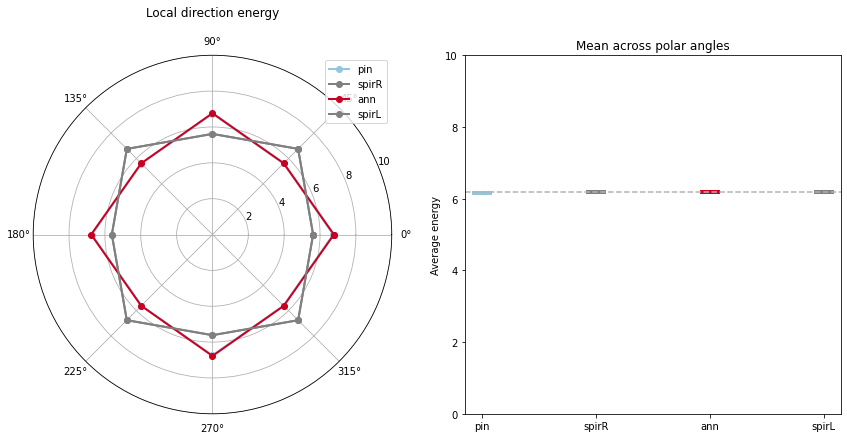

([['pin', 'spirR', 'ann', 'spirL'], ['pin', 'spirR', 'ann', 'spirL']],
 [[5.119766532545933,
   5.126074781421776,
   5.131253267665329,
   5.1260747978024765],
  [6.1704144053652215,
   6.185417708490914,
   6.197079789846587,
   6.185417546758234]])

In [55]:
utils_image.visualize_filter_magnitudes(expDen_norm_energy_aveSF, 0, scale=None, share_color_range=True, title=None,
                                        cbar=False, scale_factor=3, save_path=None)

utils_image.plot_energy_per_channel(expDen_norm_energy_aveSF, 0, pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[-.1, 2.5])

[a,b] = utils_image.plot_energy_per_stim(expDen_norm_energy_aveSF, 0, "Cartesian analysis", pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 10])
utils_image.plot_energy_per_stim(expDen_norm_energy_aveSF, 0, "Polar analysis", pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 10])



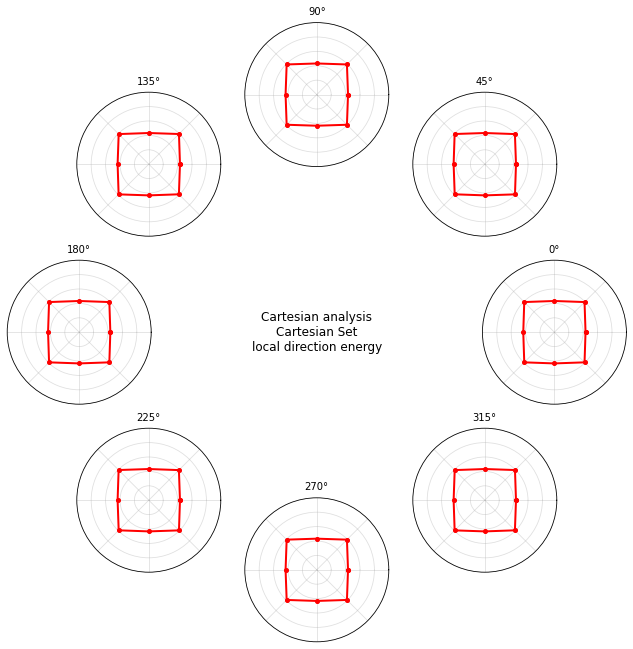

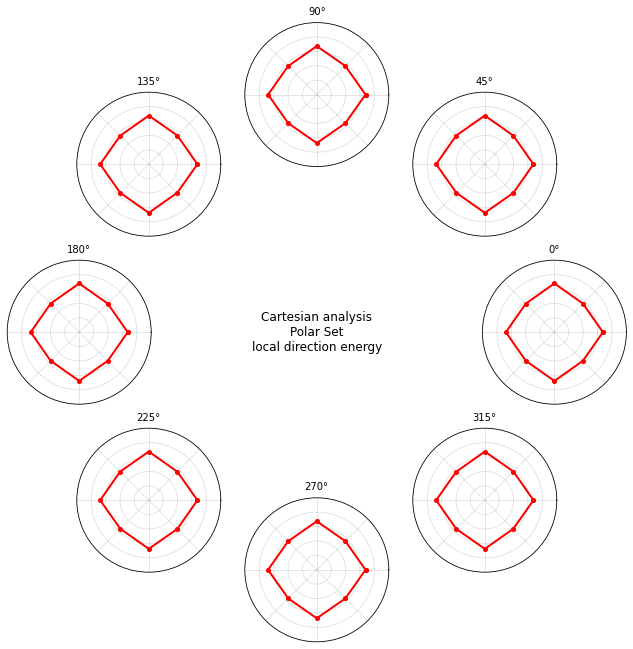

In [56]:
utils_image.plot_energy_per_location_polar(expDen_norm_energy_aveSF, 0, "Cartesian analysis",
                                   pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 10])

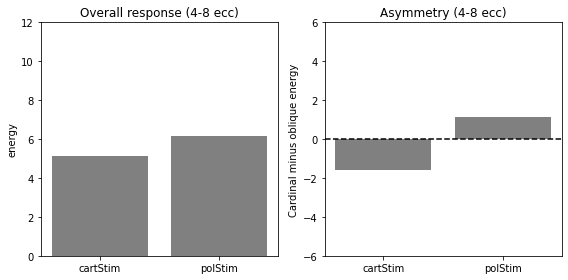

In [57]:
plot_quickView(b)

In [58]:
# ORIENTATION-TUNED NORMALIZATION
print("ORIENTATION-TUNED DIVISIVE NORMALIZATION")

orituned_norm_energy = utils_image.div_normalization(stim_energy_imb, pixpdeg, tuned=True)

orituned_norm_energy_aveSF = utils_image.condense_energy(orituned_norm_energy, dim=0, operation="mean")


ORIENTATION-TUNED DIVISIVE NORMALIZATION
k1: sf=93.68852459016394 (octaves-equiv), ori=93.68852459016394 (radians-equiv), x=93.68852459016394px, y=93.68852459016394px | k2: sf=0, ori=0, xy=0.032021 deg (1.0px)


no scale given, so computing shared scale: global min/max


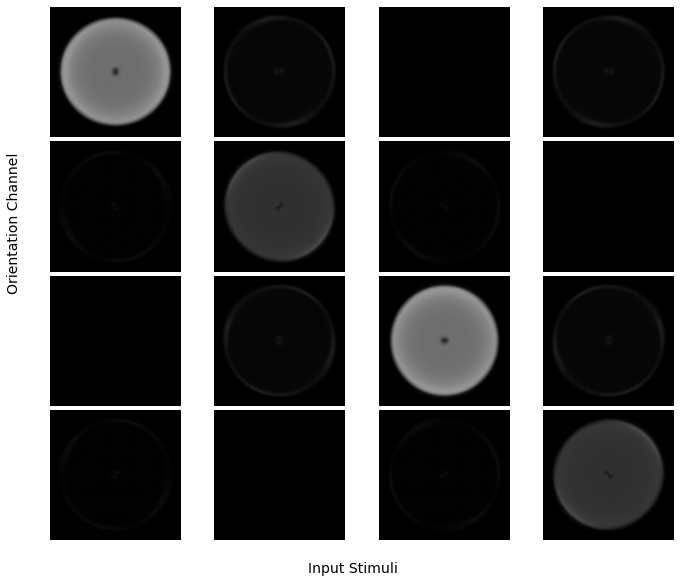

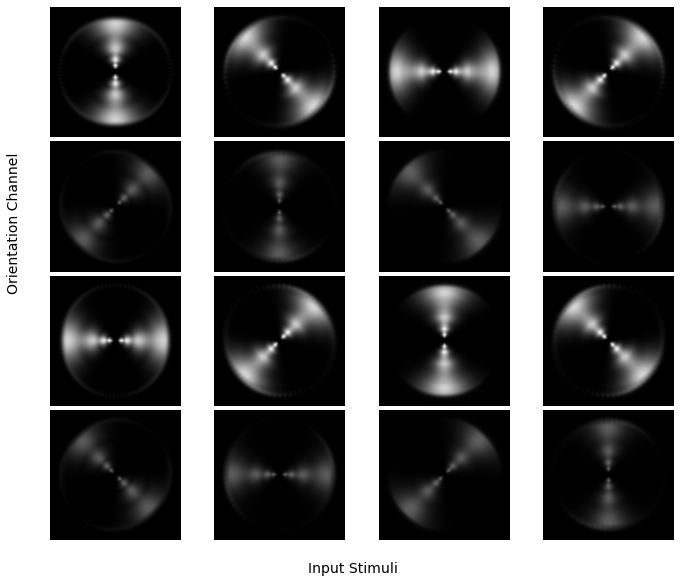

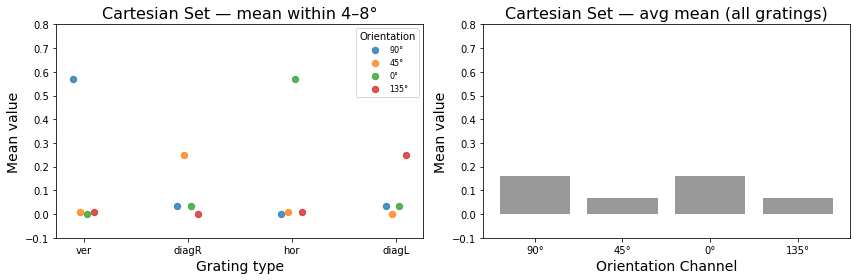

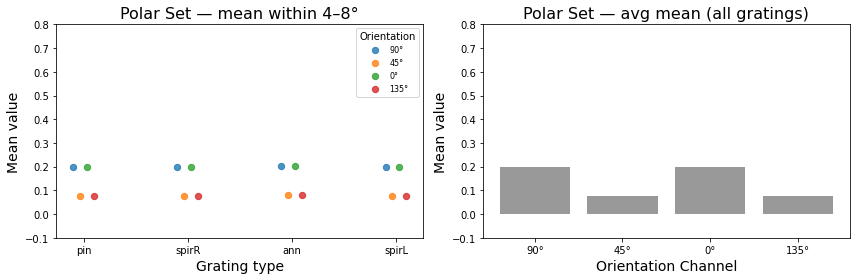

Cartesian Set
['ver', 'diagR', 'hor', 'diagL']
[0.5920795830114705, 0.31480652158041633, 0.5920795312284802, 0.3148064008426461]


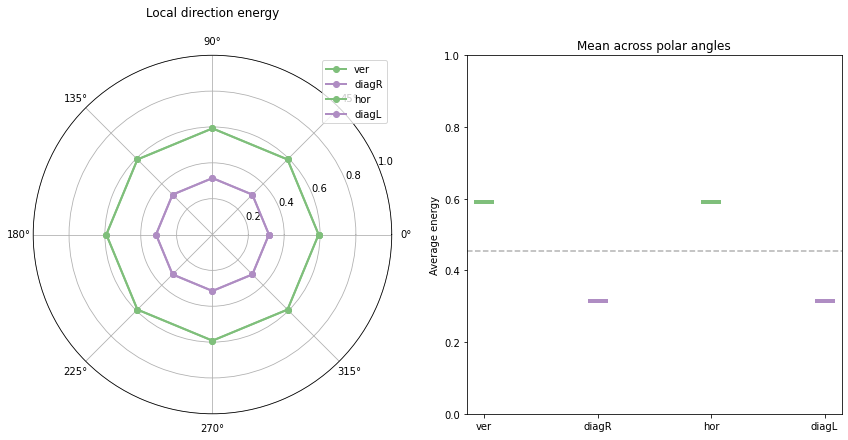

Polar Set
['ver', 'diagR', 'hor', 'diagL']
[0.6849532025434399, 0.42685629238800904, 0.6849507645478274, 0.4268576026837956]


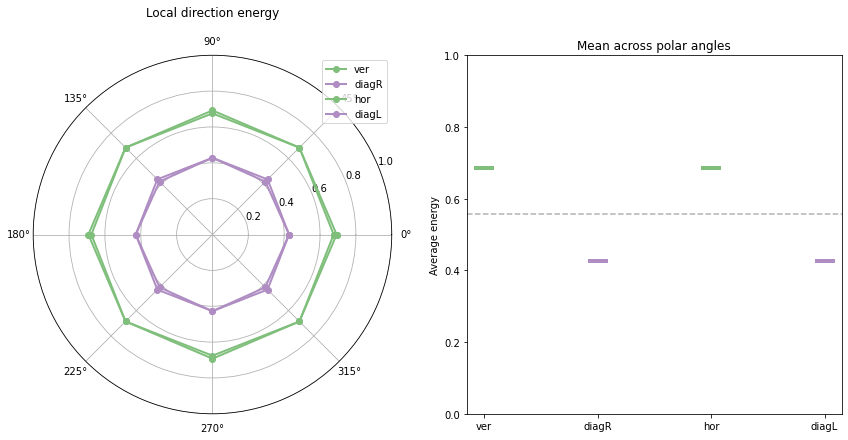

Cartesian Set
['pin', 'spirR', 'ann', 'spirL']
[0.4531381031400249, 0.4534647665651947, 0.45370440080552454, 0.45346476615226894]


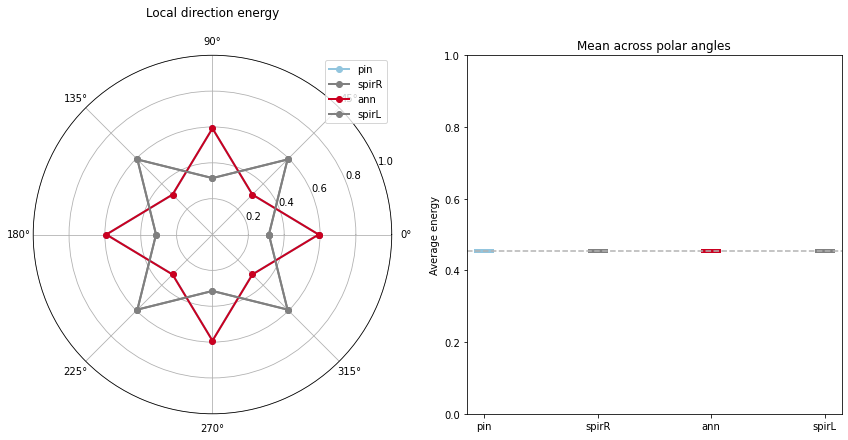

Polar Set
['pin', 'spirR', 'ann', 'spirL']
[0.5464466921253028, 0.556780284871393, 0.56361059988359, 0.5567802852827861]


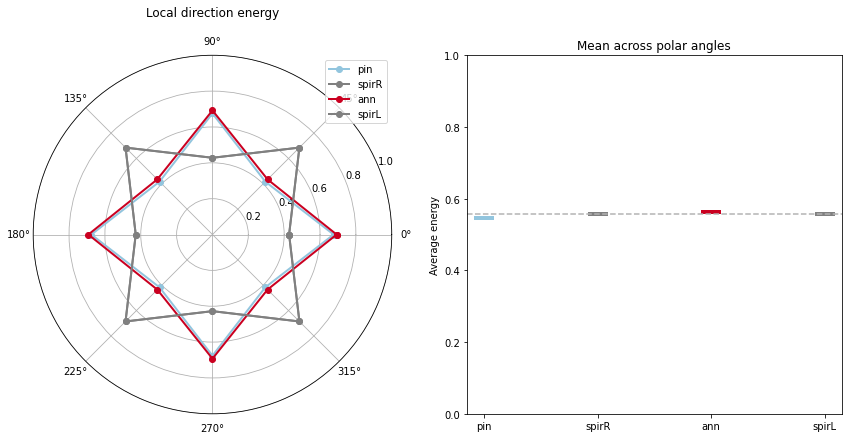

([['pin', 'spirR', 'ann', 'spirL'], ['pin', 'spirR', 'ann', 'spirL']],
 [[0.4531381031400249,
   0.4534647665651947,
   0.45370440080552454,
   0.45346476615226894],
  [0.5464466921253028,
   0.556780284871393,
   0.56361059988359,
   0.5567802852827861]])

In [59]:
utils_image.visualize_filter_magnitudes(orituned_norm_energy_aveSF, 0, scale=None, share_color_range=True, title=None,
                                        cbar=False, scale_factor=3, save_path=None)

utils_image.plot_energy_per_channel(orituned_norm_energy_aveSF, 0, pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[-.1, 0.8])

[a, b] = utils_image.plot_energy_per_stim(orituned_norm_energy_aveSF, 0, "Cartesian analysis", pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 1])

utils_image.plot_energy_per_stim(orituned_norm_energy_aveSF, 0, "Polar analysis", pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 1])


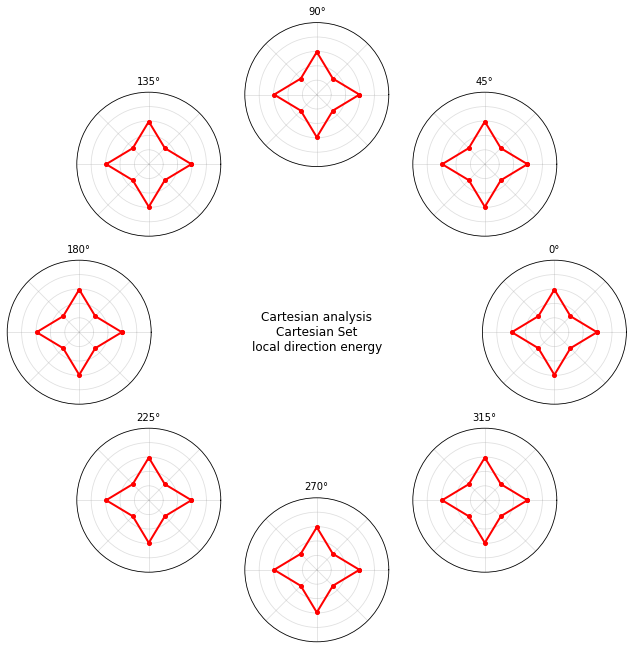

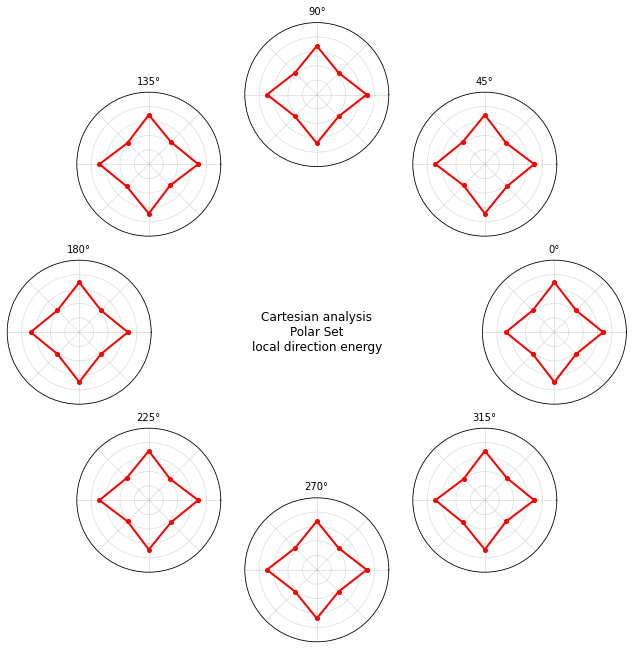

In [60]:
utils_image.plot_energy_per_location_polar(orituned_norm_energy_aveSF, 0, "Cartesian analysis",
                                   pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 1])

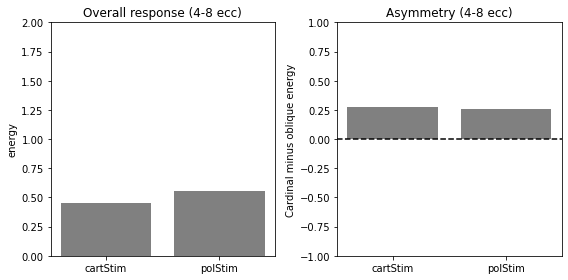

In [61]:
plot_quickView(b)

### Anisotropy model, SF preserved then collapsed afterward

Compares against `anisotropy_norm_energy2` above: SF is kept through the division (each SF channel divided independently by the same shared scalar denominator) and only averaged away afterward via `condense_energy`, instead of being averaged away before dividing. Since the denominator doesn't depend on SF, collapsing afterward should reproduce `anisotropy_norm_energy2` exactly (division by a constant commutes with averaging) -- this is a check of that, plus a look at the SF-preserved structure itself.

In [62]:
anisotropy_norm_energy_SFpreserved = utils_image.normalization_byAnisotropy_NOA(stim_energy_imb, pixpdeg)

anisotropy_norm_energy3 = utils_image.condense_energy(anisotropy_norm_energy_SFpreserved, dim=0, operation="mean")

# # sanity check: collapsing afterward should exactly reproduce the SF-collapsed version above
# max_abs_diff = max(
#     np.abs(anisotropy_norm_energy3[k] - anisotropy_norm_energy2[k]).max()
#     for k in anisotropy_norm_energy2
# )
# print("max abs diff vs. anisotropy_norm_energy2:", max_abs_diff)


no scale given, so computing shared scale: global min/max


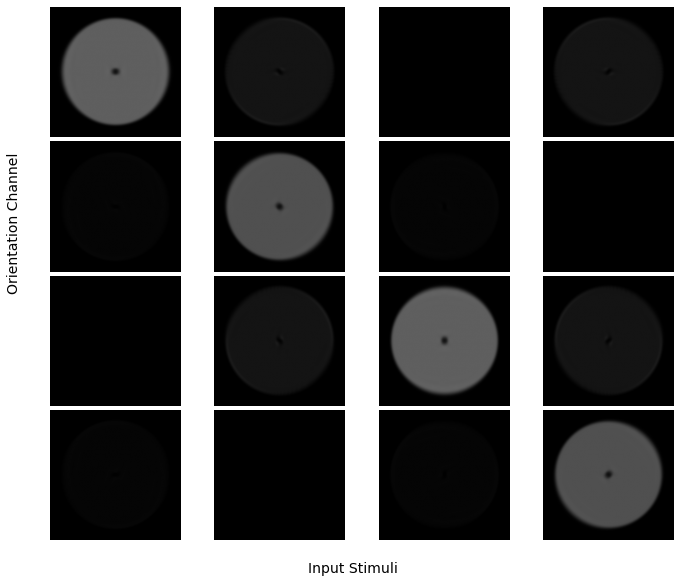

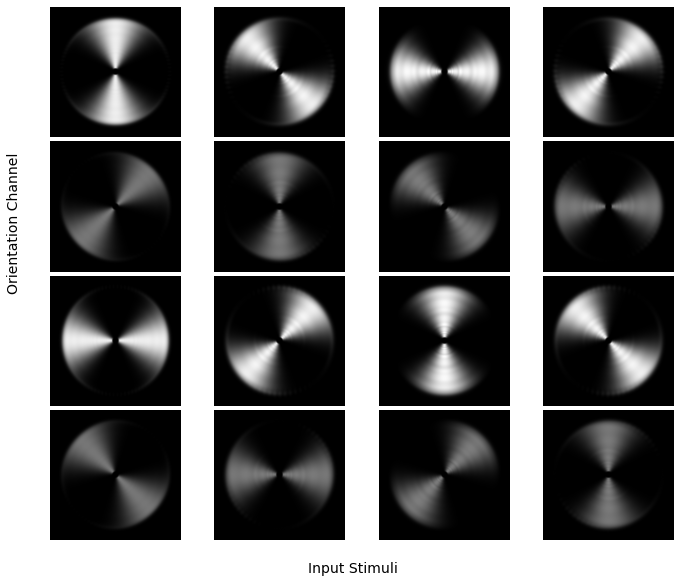

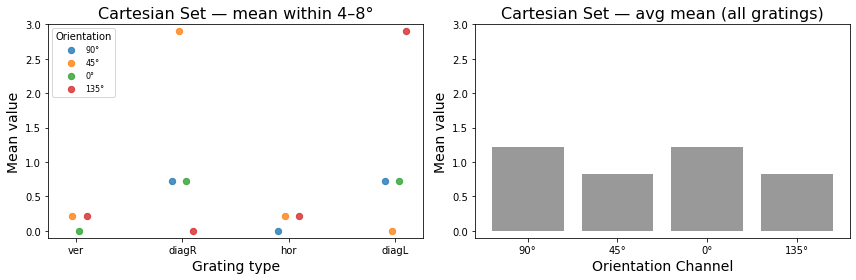

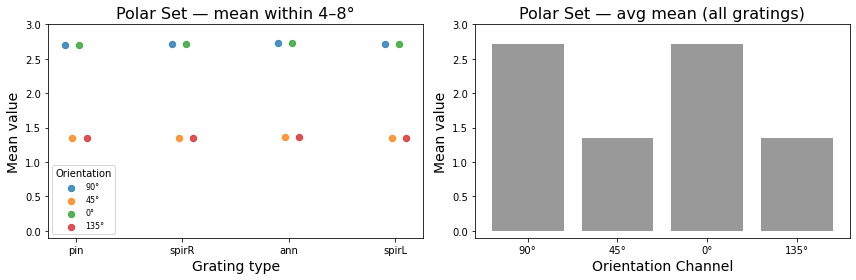

Cartesian Set
['ver', 'diagR', 'hor', 'diagL']
[3.8634391056457456, 4.3557966624753615, 3.8634390459541357, 4.355808643695055]


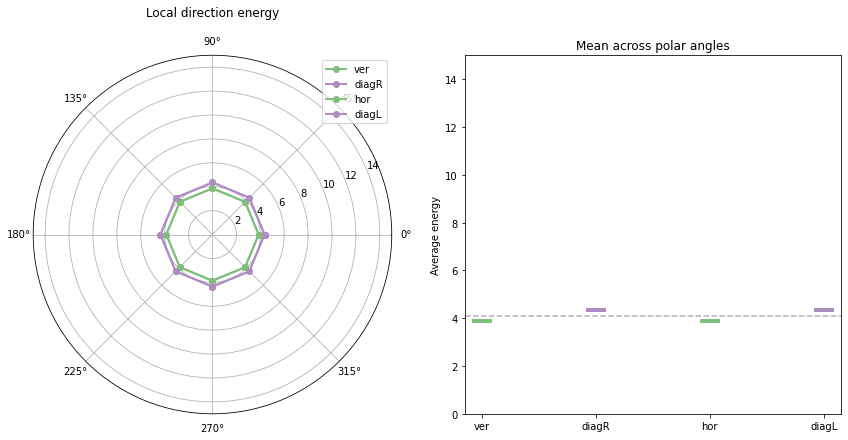

Polar Set
['ver', 'diagR', 'hor', 'diagL']
[9.154867125416914, 7.109003509745142, 9.154878042913884, 7.109010836600645]


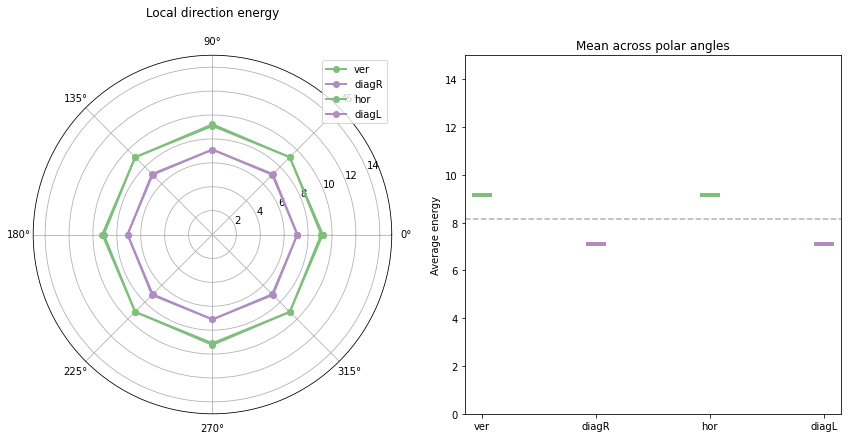

Cartesian Set
['pin', 'spirR', 'ann', 'spirL']
[4.108770540830439, 4.109873614474111, 4.109965646233994, 4.109873656231755]


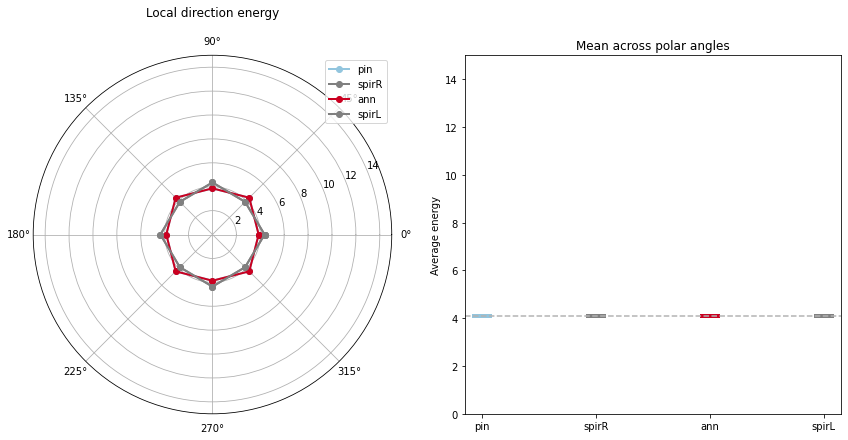

Polar Set
['pin', 'spirR', 'ann', 'spirL']
[8.08120256527018, 8.127042521344803, 8.19247189926422, 8.127042528797379]


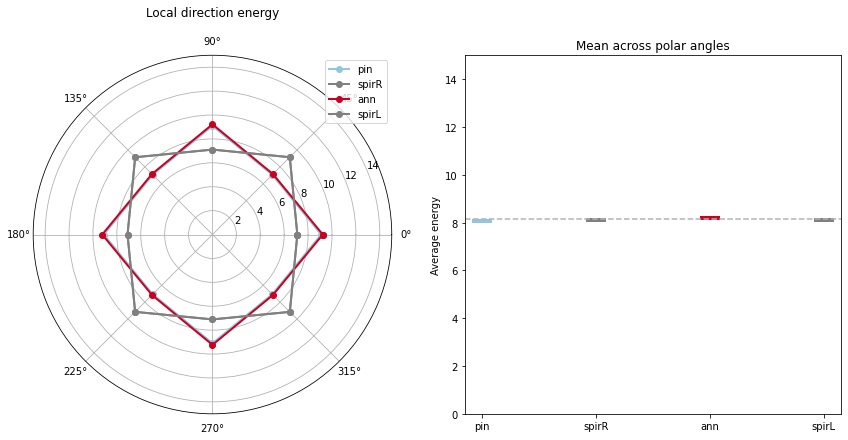

([['pin', 'spirR', 'ann', 'spirL'], ['pin', 'spirR', 'ann', 'spirL']],
 [[4.108770540830439, 4.109873614474111, 4.109965646233994, 4.109873656231755],
  [8.08120256527018, 8.127042521344803, 8.19247189926422, 8.127042528797379]])

In [63]:
utils_image.visualize_filter_magnitudes(anisotropy_norm_energy3, 0, scale=None, share_color_range=True, title=None,
                                        cbar=False, scale_factor=3, save_path=None)

utils_image.plot_energy_per_channel(anisotropy_norm_energy3, 0, pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[-0.1, 3])

[a2,b2] = utils_image.plot_energy_per_stim(anisotropy_norm_energy3, 0, "Cartesian analysis", pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 15])

utils_image.plot_energy_per_stim(anisotropy_norm_energy3, 0, "Polar analysis", pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 15])


no scale given, so computing shared scale: global min/max


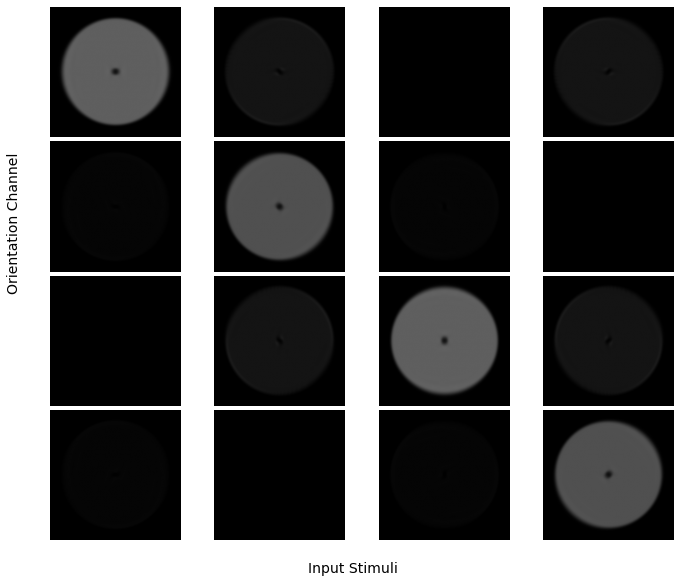

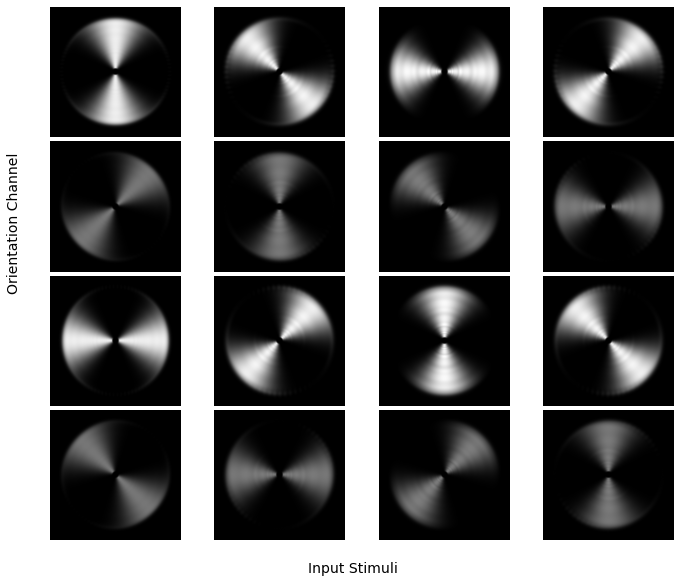

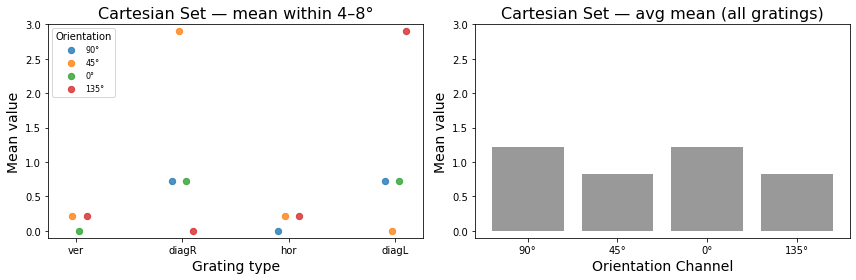

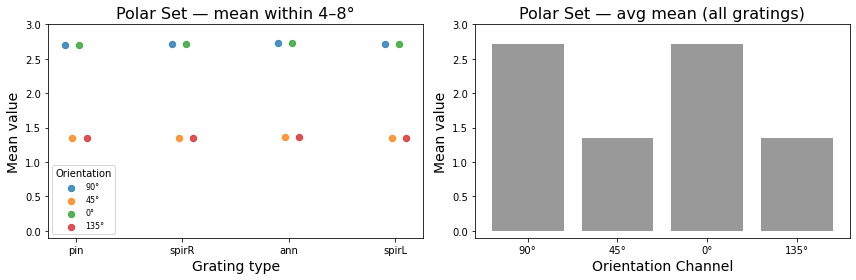

Cartesian Set
['ver', 'diagR', 'hor', 'diagL']
[3.8634391056457456, 4.3557966624753615, 3.8634390459541357, 4.355808643695055]


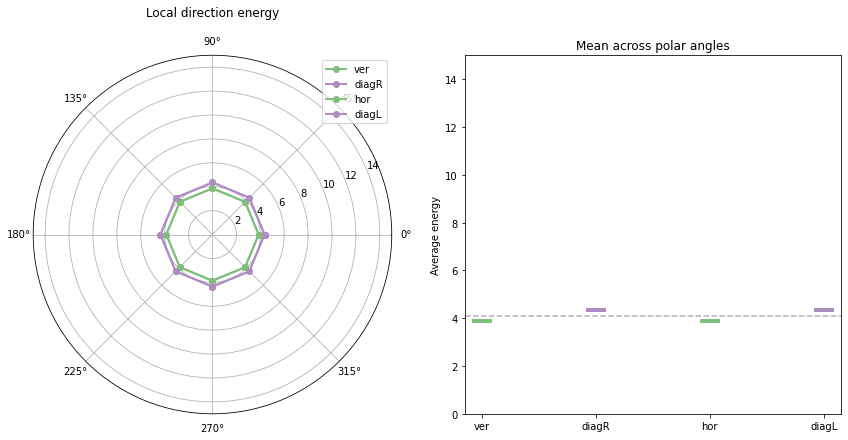

Polar Set
['ver', 'diagR', 'hor', 'diagL']
[9.154867125416914, 7.109003509745142, 9.154878042913884, 7.109010836600645]


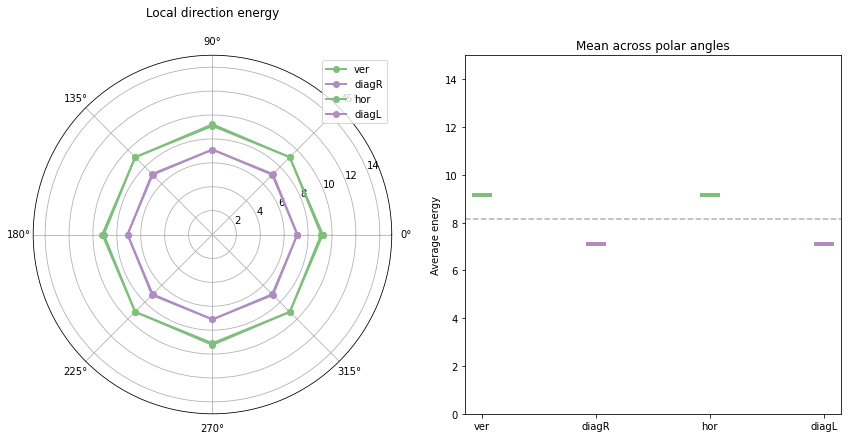

Cartesian Set
['pin', 'spirR', 'ann', 'spirL']
[4.108770540830439, 4.109873614474111, 4.109965646233994, 4.109873656231755]


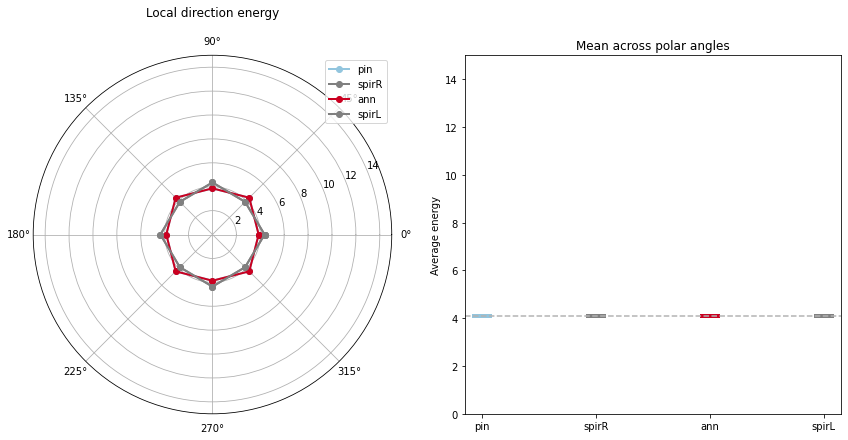

Polar Set
['pin', 'spirR', 'ann', 'spirL']
[8.08120256527018, 8.127042521344803, 8.19247189926422, 8.127042528797379]


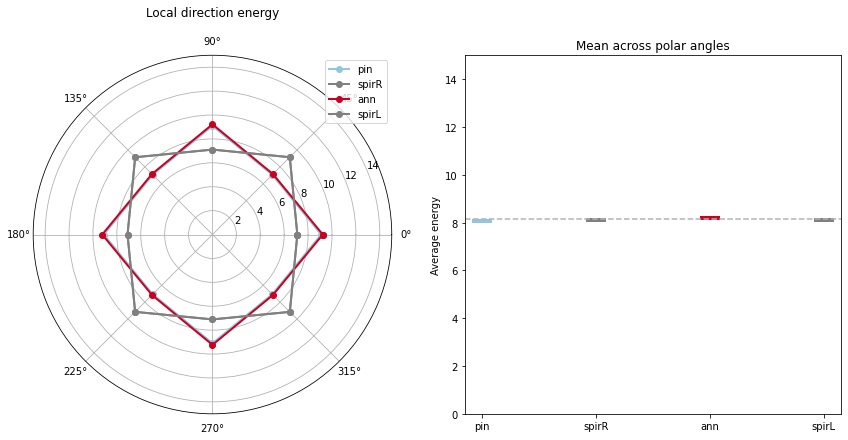

([['pin', 'spirR', 'ann', 'spirL'], ['pin', 'spirR', 'ann', 'spirL']],
 [[4.108770540830439, 4.109873614474111, 4.109965646233994, 4.109873656231755],
  [8.08120256527018, 8.127042521344803, 8.19247189926422, 8.127042528797379]])

In [64]:
utils_image.visualize_filter_magnitudes(anisotropy_norm_energy3, 0, scale=None, share_color_range=True, title=None,
                                        cbar=False, scale_factor=3, save_path=None)

utils_image.plot_energy_per_channel(anisotropy_norm_energy3, 0, pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[-0.1, 3])

[a,b] = utils_image.plot_energy_per_stim(anisotropy_norm_energy3, 0, "Cartesian analysis", pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 15])

utils_image.plot_energy_per_stim(anisotropy_norm_energy3, 0, "Polar analysis", pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 15])


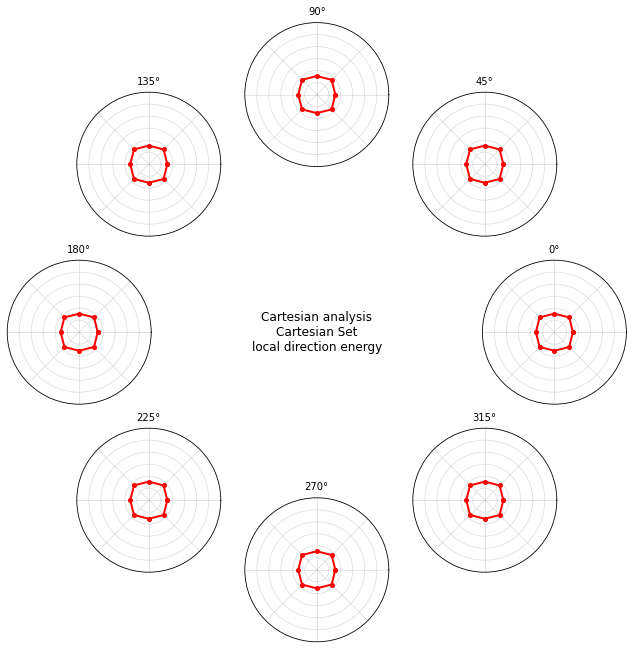

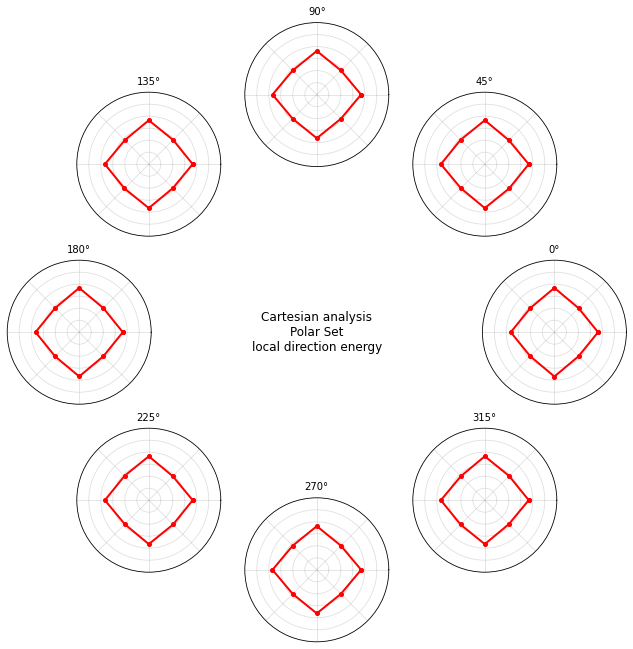

In [65]:
utils_image.plot_energy_per_location_polar(anisotropy_norm_energy3, 0, "Cartesian analysis",
                                   pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 15])

In [66]:
# center-surround stimulus homogeneity model

stimHomog_norm_energy = utils_image.normalization_byStimHomogeneity(stim_energy_imb, pixpdeg)

stimHomog_norm_energy_aveSF = utils_image.condense_energy(stimHomog_norm_energy, dim=0, operation="mean")



no scale given, so computing shared scale: global min/max


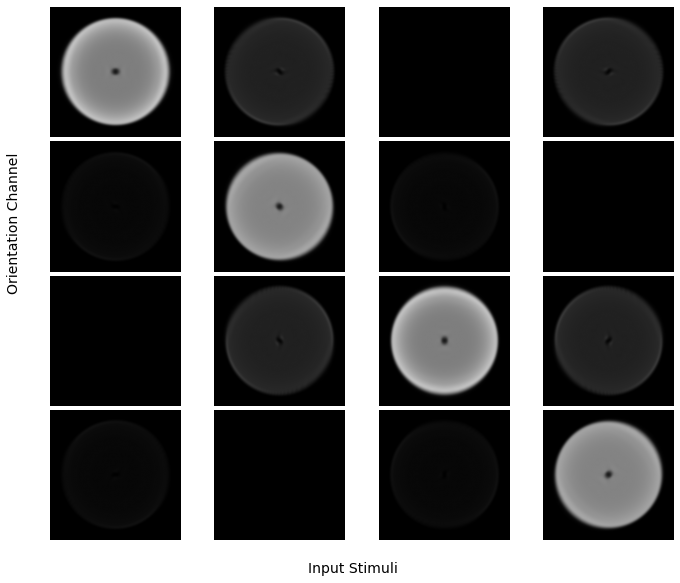

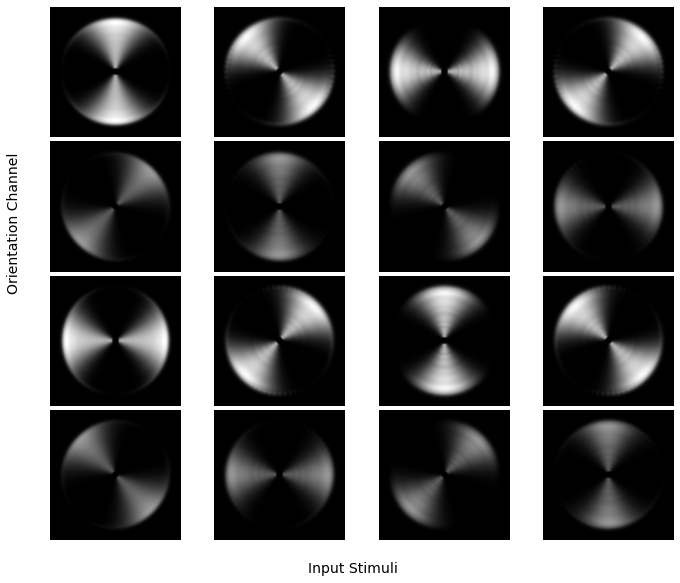

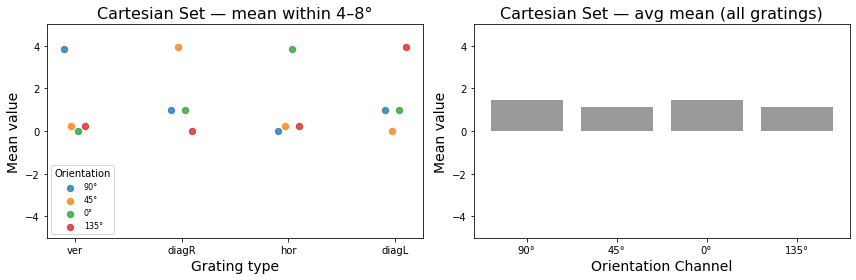

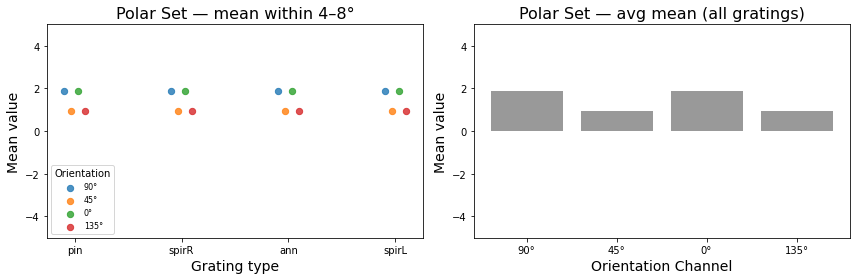

Cartesian Set
['ver', 'diagR', 'hor', 'diagL']
[4.330386923869132, 5.918941643146683, 4.330386564409064, 5.918940859572812]


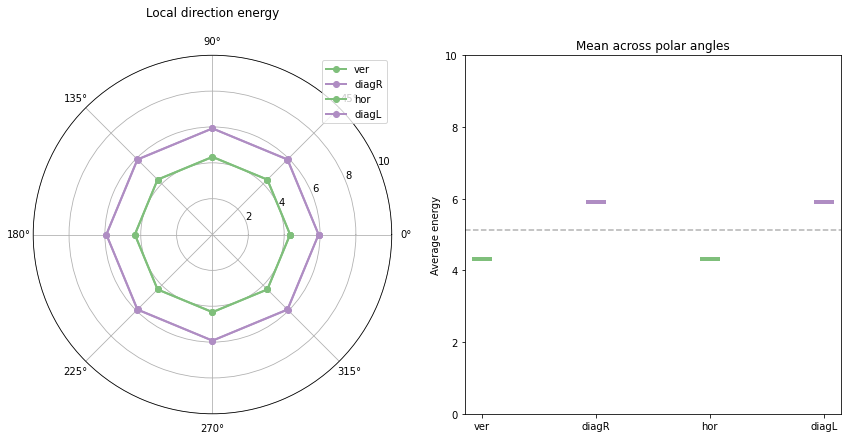

Polar Set
['ver', 'diagR', 'hor', 'diagL']
[6.176921303052236, 5.0984552883719925, 6.1769258840771215, 5.098477848460515]


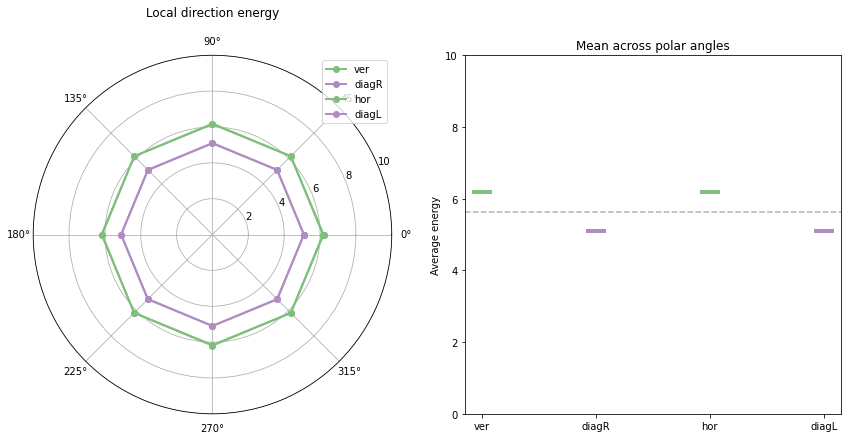

Cartesian Set
['pin', 'spirR', 'ann', 'spirL']
[5.118876704318701, 5.124947151654901, 5.129884971217232, 5.1249471638068576]


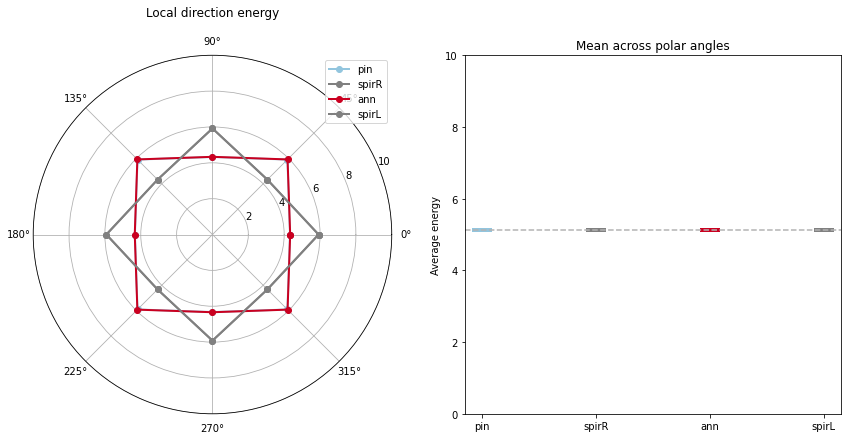

Polar Set
['pin', 'spirR', 'ann', 'spirL']
[5.625739858453575, 5.637723032033003, 5.649594326602898, 5.637723106872389]


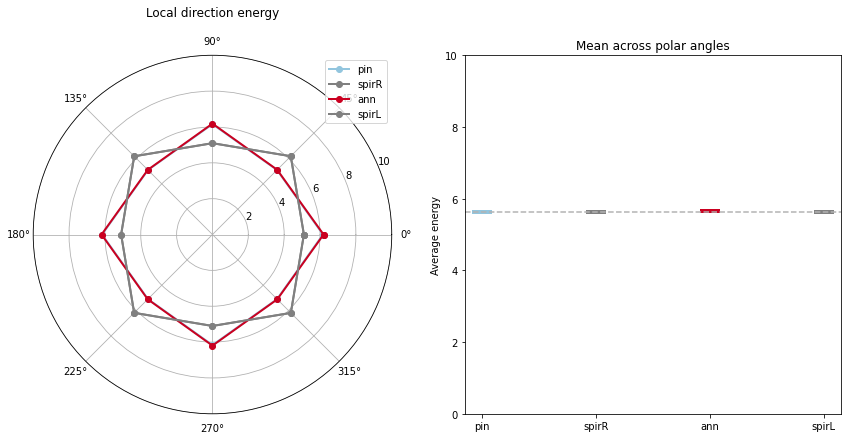

([['pin', 'spirR', 'ann', 'spirL'], ['pin', 'spirR', 'ann', 'spirL']],
 [[5.118876704318701,
   5.124947151654901,
   5.129884971217232,
   5.1249471638068576],
  [5.625739858453575,
   5.637723032033003,
   5.649594326602898,
   5.637723106872389]])

In [77]:
utils_image.visualize_filter_magnitudes(stimHomog_norm_energy_aveSF, 0, scale=None, share_color_range=True, title=None,
                                        cbar=False, scale_factor=3, save_path=None)

utils_image.plot_energy_per_channel(stimHomog_norm_energy_aveSF, 0, pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[-5, 5])

[a,b] = utils_image.plot_energy_per_stim(stimHomog_norm_energy_aveSF, 0, "Cartesian analysis", pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 10])

utils_image.plot_energy_per_stim(stimHomog_norm_energy_aveSF, 0, "Polar analysis", pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[0, 10])

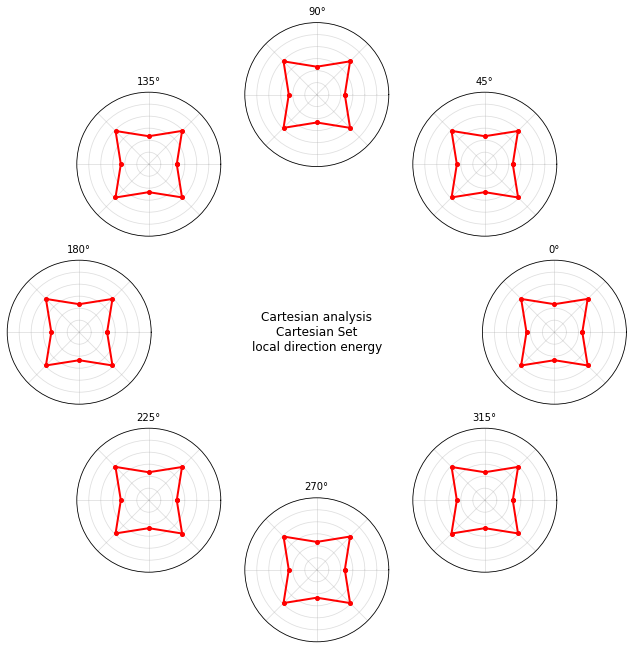

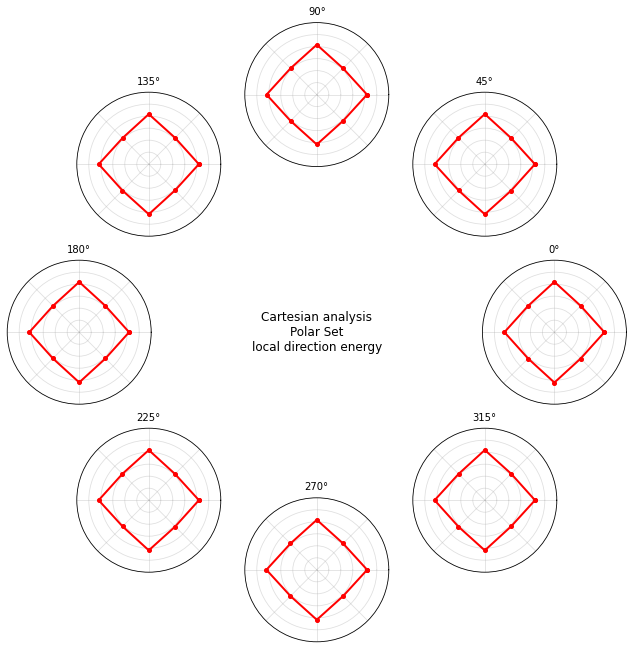

In [81]:
utils_image.plot_energy_per_location_polar(stimHomog_norm_energy_aveSF, 0, "Cartesian analysis",
                                   pixpdeg, min_ecc_deg=4, max_ecc_deg=8, yrange=[2, 8])

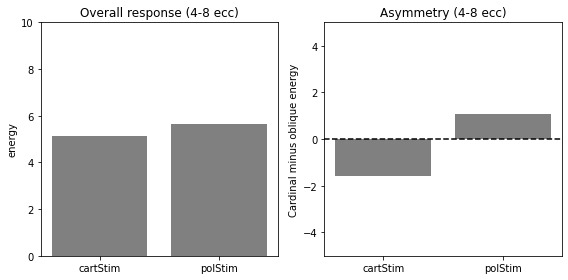

In [69]:
plot_quickView(b)

In [70]:
# def plot_homogeneity_map(homogeneity, i, j, vmin=0, vmax=1):
#     H = homogeneity[i, j]   # shape (896, 896)

#     plt.figure(figsize=(6, 6))
#     plt.imshow(H, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
#     plt.colorbar(label='Homogeneity')
#     plt.title(f'Homogeneity Map (set={i}, stim={j})')
#     plt.axis('off')
#     plt.tight_layout()
#     plt.show()

In [71]:
# plot_homogeneity_map(stimHomog_norm_energy, i=0, j=3)

In [72]:
arr = stim_energy_imb[0,0][0,0]

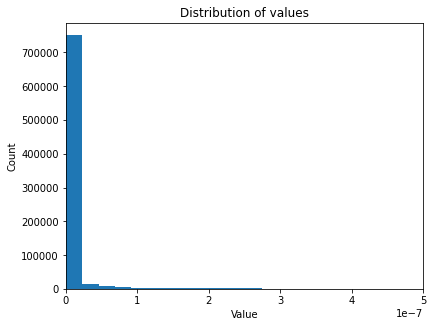

In [73]:
# Flatten to 1D
vals = arr.flatten()

# Plot histogram
plt.hist(vals, bins=100)
plt.xlabel('Value')
plt.ylabel('Count')
plt.title('Distribution of values')
plt.xlim(0, 0.0000005)
plt.show()

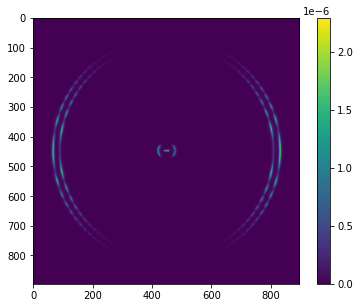

In [74]:
plt.imshow(arr)
plt.colorbar()
plt.show()